
# Introduction

This documentation outlines the method for calculating spatially
standardized latitudinal extinction gradients across stage boundaries
using fossil occurrence data from the Paleobiology Database (PBDB) used in Prow-Fleischer et al (in prep).
Consideration is made for cleaning and filtering data and documenting
each step per [Ten simple rules to follow when cleaning occurrence data
in
palaeobiology](https://tenrules.palaeoverse.org/)[@jonesTenSimpleRules2025].


# Setup

In [1]:
rpkg <- c(
  # Data manipulation
  "dplyr", "readr", "tidyr", "purrr", "conflicted",
  
  # Geospatial data manipulation
  "rgplates", "chronosphere", "icosa","terra",

  # # Accessing and cleaning paleontological occurrence data
  "CoordinateCleaner", "fossilbrush", "divvy",
  
  # # Plotting and visualization
   "ggplot2", "RColorBrewer", "DT", "patchwork", "viridis",

  # statistical analysis
    "Rfit",
    
   # for bibliography
    "rbbt")

lapply(rpkg, function(pkg) {
  tryCatch(
    library(pkg, character.only = TRUE)
  )
})|>invisible()


conflicted::conflict_prefer(name = "filter", winner = "dplyr",losers = "stats")
conflicts_prefer(terra::project)

# color blind friendly palette: okabe ito
okabe_ito_10 <- c(
  "#E69F00", # orange
  "#56B4E9", # sky blue
  "#009E73", # bluish green
  "#F0E442", # yellow
  "#0072B2", # blue
  "#D55E00", # vermillion
  "#CC79A7", # reddish purple
  "#999999", # grey
  "#E1BE6A", # tan
  "#40B0A6"  # teal
)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: sf

Linking to GEOS 3.11.2, GDAL 3.6.2, PROJ 9.2.0; sf_use_s2() is TRUE

Chronosphere - Evolving Earth System Variables
Important: never fetch data as a superuser / with admin. privileges!

Note that the package was split for efficient maintenance and development:
 - Plate tectonic calculations -> package 'rgplates'
 - Arrays of raster and vector spatials -> package 'via'

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running unde


## Custom Functions

Latitudinally bin occurrence data

In [2]:
#df is cleaned occurence dataframe, lower is list of lower latitude boundaries, 
#upper is the upper boundaries and mid are mid points for plotting purposes. T
#his function makes a copy of original df and adds the latbin column so if you are only wanting 
#to plot latitudinal distributions of taxa you can assign the midpoint lat it will plot data against (See Other Data Exploration section)

#use with divvy::bandit latitudinal subsampling
filter_bin <- function(df, lower, upper, mid) { 
  df %>%
    filter(paleolat >= lower, paleolat < upper) %>%
    mutate(latbin = mid) %>%
    distinct(genus, .keep_all = TRUE)}


# use fitler_bin_hexa recommended only for some subsampling rountine like divvy:cookies
filter_bin_hexa <- function(df, lower, upper, mid) { 
  df %>%
    filter(hexa_lat >= lower, hexa_lat < upper) %>%
    mutate(latbin = mid) %>%
    distinct(genus, .keep_all = TRUE)}

Function to calculate the percentage of genera per latitude bin that went extinct at the end of a given stage.

In [3]:
calc_extinction <- function(fossils) { #takes a dataframe with cols latbin, genus and extinct binary assignment
  
  total_genera <- fossils %>%
    group_by(latbin) %>%
    summarize(num_genera = n_distinct(genus), .groups = "drop")
  
  # Count extinct genera by exact paleolatitude
  num_extinct <- fossils %>%
    filter(ex == 1) %>% # this line selects genera that went extinct at stage boundy. To be explained in cleaning section.
    group_by(latbin) %>%
    summarize(num_extinct_genera = n_distinct(genus), .groups = "drop")
  
  # Merge totals and extinctions
  percent_extinct <- merge(num_extinct, total_genera, by = "latbin")
  # Calculate extinction percentage
  percent_extinct$percent <- round(
    percent_extinct$num_extinct_genera / percent_extinct$num_genera * 100
  )
  
  return(percent_extinct)
}


Build a hexagonal grid and re-project occurrence data to this grid

In [4]:
cell_summary <- function(data, hexa, min_occ = NULL) {
    
  # Get coords and ensure numeric
  coords <- data |> 
    select(paleolng, paleolat) |>
    mutate(across(c(paleolng, paleolat), as.numeric))
  
  # Locate cells

    cells <- locate(hexa, as.matrix(coords))
  
  # Count occurrences per cell
  cell_counts <- tibble(cell = cells) |> 
    group_by(cell) |> 
    summarise(occurrences = n(), .groups = "drop")
  
  
  # Optionally filter by min_occ
  if (!is.null(min_occ)) {
    
   dropped <- cell_counts %>% filter(occurrences < min_occ)
  
  # Print removed cells
  if (nrow(dropped) > 0) {
    cat("The cells that were flagged are:\n")
    print(dropped$cell)
  } else {
    cat("No cells were flagged.\n")
  }
  
  # Keep only cells meeting min_occ
  cell_counts <- cell_counts %>% filter(occurrences >= min_occ)
  }
  
  return(cell_counts)
}

# Clean Fossil Occurrence Data

## Data Aquisition

In [5]:
#data aquisition: download data from pbdb and save it
interval = "Devonian"

output = "class,coords,paleoloc,env,ref"

query <- paste0("https://paleobiodb.org/data1.2/occs/list.csv?datainfo&rowcount&interval=", interval, "&pgm=gplates&show=", output)
# download.file(query, destfile = "..data_files/fossil_occs_datafiles/Devonian_pbdb_data.Feb2026.csv", mode = "wb") # Do only once

# Read occurrence dataset.
data =  "../data_files/fossil_occs_datafiles/Devonian_pbdb_data.Feb2026.csv"
pbdb_long <-read.csv(file = data, skip = 18, header = TRUE)

meta<- read.csv(data, nrows =7, header= FALSE)

meta


V1,V2
<chr>,<chr>
Data Provider,The Paleobiology Database
Data Source,The Paleobiology Database
Data License,Creative Commons CC0
License URL,https://creativecommons.org/publicdomain/zero/1.0/
Documentation URL,http://paleobiodb.org/data1.2/occs/list_doc.html
Data URL,"http://paleobiodb.org/data1.2/occs/list.csv?datainfo&rowcount&interval=Devonian&pgm=gplates&show=class,coords,paleoloc,env,ref"
Access Time,Sat 2026-02-21 21:51:10 GMT


Get the ages that the PBDB uses for the boundary under investigation 

In [6]:
# download.file("https://paleobiodb.org/data1.2/intervals/list.txt?scale=1", destfile = "../data_files/stages.csv", , mode = "wb")

intervals<-read.csv("../data_files/stages.csv")
head(intervals)

,interval_no,record_type,scale_no,interval_name,abbrev,type,parent_no,color,t_age,b_age,reference_no
,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<int>
1,751,int,1,Phanerozoic,,eon,NA,#9AD9DD,0.0000,538.8000,87596
2,1,int,1,Cenozoic,Cz,era,751,#F2F91D,0.0000,66.0000,87596
3,12,int,1,Quaternary,Q,period,1,#F9F97F,0.0000,2.5800,87596
4,32,int,1,Holocene,,epoch,12,#FEF2E0,0.0000,0.0117,87596
5,1200,int,1,Meghalayan,,age,32,#FEF2E0,0.0000,0.0042,87596
6,1201,int,1,Northgrippian,,age,32,#FEF2E0,0.0042,0.0082,87596


In [7]:
# get the upper and lower boundaries for the Frasnian
fras <- intervals%>%filter(interval_name == "Frasnian")

lower <- fras %>% pull(t_age) # lower being younger
lower
upper <- fras %>% pull(b_age)
upper

[1] 372.15

[1] 382.31

## Data Cleaning

Data pre-processing made use of functions from the `fossilbrush`
[@flannery-sutherland2022]and `CoordinateCleaner` [@zizka2019]R
packages.

Remove incorrect paleo-coordinates. Unify Taxonomic names.

In [8]:
# Identify Invalid Coordinates.
  cl <- cc_val(pbdb_long, value = "flagged", lat="paleolat", lon  ="paleolng") #flags incorrect coordinates
  cl_rec <- pbdb_long[!cl,] #extract and check them
  
 pbdb_pbdb_long <- pbdb_long %>% 
   cc_val(lat = "paleolat", lon="paleolng") #remove them
 
# Use fossilbrush to clean taxonomic errors
b_ranks <- c("phylum", "class", "order", "family", "genus") #accepted_name is genus name

# Define a list of suffixes to be used at each taxonomic level when scanning for synonyms
b_suff = list(NULL, NULL, NULL, NULL, c("ina", "ella", "etta"))

pbdb2 <- check_taxonomy(pbdb_long, suff_set = b_suff, ranks = b_ranks, verbose = FALSE,
                         clean_name = TRUE, resolve_duplicates = TRUE, jump = 5)
# resolves homonyms, and jump refers to which taxonomic rank is the highest we resolve to. jump = 5 will stop before phylum since phylum level usually has little error.


pbdb_cleaned <- pbdb2$data[1:nrow(pbdb_long),]

Testing coordinate validity

Flagged 1871 records.

Testing coordinate validity

Removed 1871 records.

Checking formatting [1/4]



 + cleaning names at rank genus         


Checking spelling   [2/4]

Checking ranks      [3/4]

Checking taxonomy   [4/4]



 + resolving duplicates at rank class       


## Data Filtering

Add a binary value for whether a genus went extinct at the FF boundary then filter the dataset down to occurrences that exist during the Fransian stage. 

In [9]:
pbdb_cleaned <-pbdb_cleaned %>% group_by(genus)%>%mutate(lad = min(min_ma, na.rm=TRUE), fad = max(max_ma, na.rm =TRUE))%>% ungroup()
# pbdb_cleaned %>%group_by(fad)%>%summarise() #test
pbdb_cleaned$ex <-0
pbdb_cleaned$ex[pbdb_cleaned$lad==lower] <- 1 #if lad coincides with stage boundary make a 1

In [10]:
#keep only Fransian occs

# filter first by fad/lad, this effectively aggregates occs
pbdb_filtered <- pbdb_cleaned %>%
  filter(!(fad > upper & (lad > lower & lad < upper)) & # remove occs originated before gf and went extinct before ff
         !(fad <= upper & (lad > lower & lad < upper)) & # remove occs originated during frasnian and went extinct before ff
         !(fad > upper & lad > upper) & # remove occs fad and lad before the frasnian
         !(fad < lower)) # remove occs that originated after frasnian

# this filters out individual occurrences to retain only those with min and max_ma within the Frasnian
pbdb_filtered <- pbdb_filtered %>% 
  filter(max_ma <= upper & min_ma >= lower) 

head(pbdb_filtered, 5)


occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,⋯,paleomodel,geoplate,paleoage,paleolng,paleolat,environment,primary_reference,lad,fad,ex
<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
10983,occ,NA,,628,Amphipora sp.,genus,3346,,Amphipora,⋯,gplates,101,mid,-57.56,-9.29,peritidal,"J. E. Klovan. 1964. Facies analysis of the Redwater Reef Complex, Alberta, Canada. Bulletin of Canadian Petroleum Geology 12:1-100",358.86,443.10,0
10984,occ,NA,,628,Archaeogastropoda indet.,order,8515,,Archaeogastropoda,⋯,gplates,101,mid,-57.56,-9.29,peritidal,"J. E. Klovan. 1964. Facies analysis of the Redwater Reef Complex, Alberta, Canada. Bulletin of Canadian Petroleum Geology 12:1-100",298.90,443.10,0
10985,occ,NA,,628,Megalodon sp.,genus,18606,,Megalodon,⋯,gplates,101,mid,-57.56,-9.29,peritidal,"J. E. Klovan. 1964. Facies analysis of the Redwater Reef Complex, Alberta, Canada. Bulletin of Canadian Petroleum Geology 12:1-100",372.15,419.62,1
10986,occ,NA,,629,Metriophyllum sp.,genus,5632,,Metriophyllum,⋯,gplates,101,mid,-57.56,-9.29,shallow subtidal indet.,"J. E. Klovan. 1964. Facies analysis of the Redwater Reef Complex, Alberta, Canada. Bulletin of Canadian Petroleum Geology 12:1-100",358.86,413.02,0
10987,occ,NA,,629,Thamnopora sp.,genus,5086,,Thamnopora,⋯,gplates,101,mid,-57.56,-9.29,shallow subtidal indet.,"J. E. Klovan. 1964. Facies analysis of the Redwater Reef Complex, Alberta, Canada. Bulletin of Canadian Petroleum Geology 12:1-100",358.86,422.70,0


Next filter to include only select paleoenvironments. Here, we only want
to *include* marine environments.

In [11]:
#what type of environments are represented
 
 pbdb_environments<- pbdb_filtered %>% 
  summarise(unique_ = list(unique(environment)))
 
#Include only marine environments
 
 pbdb_filtered <- pbdb_filtered %>% 
  filter(environment %in% c("carbonate indet.", "marine indet.", 
                            "deep subtidal shelf", 
                            "lagoonal/restricted shallow subtidal", 
                            "perireef or subreef", "offshore", 
                            "offshore indet.", "basinal (siliceous)",
                            "peritidal", "deep-water indet.", "offshore ramp",
                            "shallow subtidal indet.", "offshore shelf",
                            "basinal (carbonate)", "open shallow subtidal", 
                            "deep subtidal indet.", "lagoonal", 
                            "coastal indet.", "slope", 
                            "platform/shelf-margin reef",
                            "intrashelf/intraplatform reef", "shoreface", 
                            "deep subtidal ramp", "slope/ramp reef")) 
 
cat("The number of entries is now:", nrow(pbdb_filtered), "\n")


The number of entries is now: 9311 


In [12]:
#
pbdb_phyla<- pbdb_filtered %>% 
  group_by(phylum) %>% 
  summarise(unique_phylum = list(unique(phylum)))
 
pbdb_classes<- pbdb_filtered %>% 
  group_by(phylum) %>% 
  summarise(unique_classes = list(unique(class)))
 
 #pbdb_classes[[1]] #prints out the phyla
 
 
 #pbdb_classes[[2]] #prints out all the classes
 
 print(pbdb_phyla) 

# A tibble: 25 × 2
   phylum           unique_phylum
   <chr>            <list>       
 1 Aneurophytophyta <chr [1]>    
 2 Annelida         <chr [1]>    
 3 Arthropoda       <chr [1]>    
 4 Brachiopoda      <chr [1]>    
 5 Bryozoa          <chr [1]>    
 6 Chlorophyta      <chr [1]>    
 7 Chordata         <chr [1]>    
 8 Cnidaria         <chr [1]>    
 9 Coniferophyta    <chr [1]>    
10 Cyanobacteria    <chr [1]>    
# ℹ 15 more rows


### Partition by taxonomic group

In [13]:
# keep only marine phyla
pbdb_filtered <- pbdb_filtered %>%
  filter(phylum %in% c("Brachiopoda",
    "Mollusca", "Annelida", "Chordata", "Arthropoda", "Bryozoa", "Cnidaria", "Echinodermata", "Porifera"))

# print unique classes for each phylum
 
 pbdb_classes<- pbdb_filtered %>% 
  group_by(phylum) %>% 
  summarise(unique_classes = list(unique(class)))
 
 datatable(pbdb_classes) 

cat("The number of entries is now:", nrow(pbdb_filtered), "\n")

pbdb_filtered %>%
  distinct(genus, .keep_all = TRUE) %>%
  count(ex) # rough estimate of genus exintion ~50% global (checks with other previous estimates)

HTML widgets cannot be represented in plain text (need html)

The number of entries is now: 8771 


ex,n
<dbl>,<int>
0,349
1,384


Filter dataset for remaining groups you want to *exclude* by classes. We
retained groups with 'no class specified' because those occurrences
still had genera assignments.

Other analyses included categorizing taxa into different groups such as
carbonate mineralogy [@kiessling2008], closed vs. open circulatory
systems, and Paleozoic vs. Modern taxa [@sepkoski1981] to examine
extinction selectivity.


In [14]:
# Additional filtering steps

#groups to exclude // microfossils (e.g., Conodonta)

#pbdb_filtered <- pbdb_filtered %>% filter(!class %in% c("NO_CLASS_SPECIFIED"))


######################## Categorizing taxa ############################

# Uncomment relevant section for analysis or leave commented for all taxa (CTRL+SHIFT+C on Win)

#--------------biocalcification: calcite vs aragonite ---------------
# Designations summarized in Kiessling et al. 2008

# carbonate_phyla <- pbdb_filtered %>%
#   filter(phylum %in% c("Mollusca", "Brachiopoda", "Cnidaria", 
#                        "Bryozoa", "Hyolitha")) %>%
#   filter(!class %in% c("Hexactinellida", "Hydrozoa", "Scyphozoa", 
#                        "Lingulata", "Demospongiae"))
# #aragonite 
# aragonite_groups <- carbonate_phyla %>%
#   filter(class == "Bivalvia" | order == "Murchisoniina" | family == "Labechiidae")
# 
# #calcite
# 
# calcite_groups <- carbonate_phyla %>%
#   anti_join(aragonite_groups, by = colnames(carbonate_phyla))
# 
# pbdb_filtered <-calcite_groups

#---------------closed vs open circulatory system ------------------

#closed: Cephalopoda, Chordata, Annelida

# closed_circulation <- pbdb_filtered %>%
#   filter(phylum %in% c(
#     "Mollusca", "Annelida", "Chordata"),
#          interval.ma %in% c(372.15,358.86))
# # #
# closed_circulation <- closed_circulation %>% filter(!class %in% c("Gastropoda", "Bivalvia", "Paragastropoda", "Rostroconchia", "Tergomya", "Polyplacophora", "Scaphopoda"))
# # #
# pbdb_filtered <- closed_circulation

###########

# #open: other groups except Brachiopods
# #
# open_circulation <- pbdb_filtered %>%
#    filter(phylum %in% c(
#      "Mollusca", "Arthropoda", "Bryozoa", "Cnidaria", "Echinodermata", "Porifera"))
# # # #
# # # #
#  open_circulation <- open_circulation %>% filter(!class %in% c("Cephalopoda"))
# # # # #
# # #
# pbdb_filtered <- open_circulation

# ##########

# #brachiopods
# 
# brachiopods <- pbdb_filtered %>%
#   filter(phylum %in% c(
#     "Brachiopoda"),
#          interval.ma %in% c(372.15,358.86))
# 
# pbdb_filtered <- brachiopods
# # #
# 

#---------------Modern vs Paleozoic taxa
# Sepkoski 1981

#Paleozoic

#paleozoic <- c("Rhynchonellata", "Crinoidea", "Anthozoa", "Ostracoda", "Cephalopoda", "Stenolaemata", "Asteroidea", "Ophiuroidea", "Graptolithina", "Graptolithoidea")

#modern <- c("Bivalvia", "Gastropoda", "Gymnolaemata", "Malacostraca", "Demospongiae", "Rhizopodea", "Osteichthyes", "Teleostei", "Elasmobranchii", "Holocephali", "Chondrichthyes", "Echinoidea" )

#pbdb_filtered <- pbdb_filtered %>% filter(class %in% modern)



# phyla with three lat bands of geographic range

range <- pbdb_filtered %>%
   filter(phylum %in% c(
     "Mollusca", "Arthropoda", "Cnidaria", "Chordata", "Brachiopoda"))



pbdb_filtered <- range

#----------------Save Results

pbdb_classes<- pbdb_filtered %>% 
  group_by(phylum) %>% 
  summarise(unique_classes = list(unique(class)))

print(pbdb_classes)

cat("The number of entries is now:", nrow(pbdb_filtered), "\n")


# A tibble: 5 × 2
  phylum      unique_classes
  <chr>       <list>        
1 Arthropoda  <chr [5]>     
2 Brachiopoda <chr [5]>     
3 Chordata    <chr [11]>    
4 Cnidaria    <chr [3]>     
5 Mollusca    <chr [6]>     
The number of entries is now: 8179 


Choose to remove genera (accepted_name) singletons. We did not remove
singletons from this analysis.

In [15]:
nmFreq <- table(pbdb_cleaned$genus)
sss <- nmFreq[nmFreq == 1] |> names()
sssRows <- pbdb_cleaned$genus %in% sss
pbdb_cleaned_nosingle <- pbdb_cleaned[ !sssRows, ]#assign to a new df

cat("there are", length(sss), " genera singletons in this dataset \n")


there are 1712  genera singletons in this dataset 


Final step, if necessary for your analysis, is to separate occurrences
into new data frames for each stage/time bin. At this point you can
select multiple stages to examine, here we only look at the Frasnian.


In [16]:
pbdb.2stage <- pbdb_filtered #making a copy 

cat("The number of occurrences that belong to the stage interval is:", nrow(pbdb.2stage),"\n")

cat("The number of unique genera globally is:", length(unique(pbdb.2stage$genus)), "\n")


The number of occurrences that belong to the stage interval is: 8179 
The number of unique genera globally is: 620 


Save the references for the occurrence data you kept

In [17]:
# keep only unique references

refs <- pbdb.2stage %>% 
        distinct(primary_reference)

# write.csv(refs, "../data_files/fossil_occs_datafiles/pbdb_references.csv")


In [18]:
# Select variables.
pbdb.2stage <- pbdb.2stage %>% 
  select(any_of(c("early_interval","occurrence_no","fad","lad",
                  "accepted_name","lat","lng","ex","phylum","class","family","genus",
                  "paleolat","paleolng","collection_no","environment")))

# write.csv(pbdb.2stage,"../data_files/fossil_occs_datafiles/cleaned_Frasnian_occs_open.csv")

# Data Exploration

In [44]:
# read in the cleaned dataset from file, if not continuing from above. The below code should theoretically work for any event that is saved as a csv like above
# pbdb.2stage<-read.csv("../data_files/fossil_occs_datafiles/cleaned_Frasnian_occs_allphyla.csv")

pbdb.2stage<-read.csv("../data_files/fossil_occs_datafiles/cleaned_Frasnian_occs.csv")

In [45]:
#| include: false
#Plot number of occurrences per phyla by stage

stage_interval_occurrences<-pbdb.2stage %>% 
  group_by(phylum) %>% 
  count() %>% 
  ggplot(mapping = aes(x = phylum, y = n, fill = phylum)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = n), vjust = -0.2, size = 2) +
  labs(x = NULL, y = "Number of Occurrences") +
  ggtitle("Number of Occurrences per Phyla") +
 scale_fill_manual(values = okabe_ito_10)+ 
  # facet_wrap(.~ early_interval, scales = "free_y") + 
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 8, face = "bold"),
    axis.title = element_text(size = 8, face = "bold"),
    axis.text = element_text(size = 8),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(face = "bold"),
    legend.position = "none",
    aspect.ratio = 1
  )
# stage_interval_occurrences

In [46]:
#| include: false
#Plot number of unique genera per phyla.
stage_genus_counts <- pbdb.2stage %>%
  distinct(phylum, genus) %>%
  group_by(phylum) %>%
  summarise(n = n(), .groups = "drop")

stage_interval_genus_occurrences <- stage_genus_counts %>%
  ggplot(aes(x = phylum, y = n, fill = phylum)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = n), vjust = -0.2, size = 2) +
  labs(x = NULL, y = "Number of Unique Genera") +
  ggtitle("Unique Genera per Phylum per Stage") +
  # scale_fill_brewer(palette = okabe_ito_10) +
  scale_fill_manual(values = okabe_ito_10)+
  # facet_wrap(~ early_interval, scales = "free_y") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 8, face = "bold"),
    axis.title = element_text(size = 8, face = "bold"),
    axis.text = element_text(size = 8),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(face = "bold"),
    legend.position = "none",
    aspect.ratio = 1
  )
# stage_interval_genus_occurrences

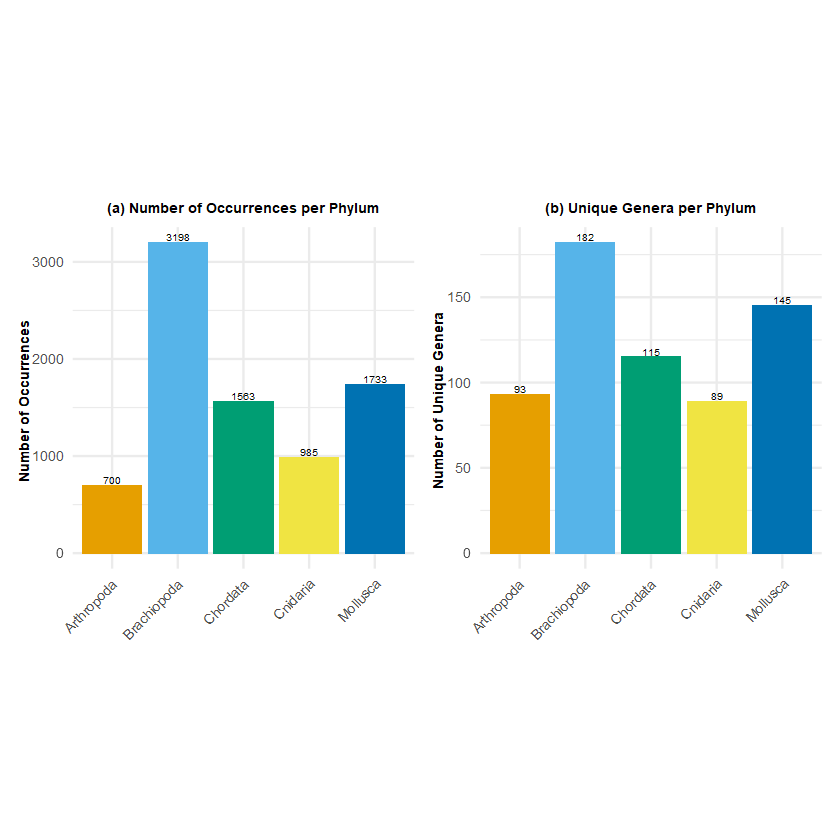

In [47]:
# Combine plots with panel labels

raw_occurences<- (stage_interval_occurrences + 
   ggtitle("(a) Number of Occurrences per Phylum"))+
(stage_interval_genus_occurrences + 
   ggtitle("(b) Unique Genera per Phylum"))

raw_occurences

**Figure 1***.* (a) Number of fossil occurrences for each phylum in the
Frasnian Stage. (b) Number of unique genera in each phylum

In [48]:
#| include: false
# ggsave("Figures/Frasnian_fossil_occ.png", plot = stage_interval_occurrences, width = 8, height = 6, dpi = 300)
# 
# ggsave("Figures/Frasnian_generic_occ.png", plot = stage_interval_genus_occurrences, width = 8, height = 6, dpi = 300)
# 
# ggsave("../figures/frasnian_occurences.png", plot = raw_occurences, width = 8, height = 6, dpi = 300)


# Spatial Analysis

Next, visualize all spatial occurrences for each stage, using the
package `rgplates` [@kocsis2025]and `icosa` [@kocsis2017]on R. Please
note that this version requires that you have the `Gplates` software
installed in your computer, as it is the most optimal version of
`rgplates`.

This chunk navigates to a local directory in which rgplates is
installed,extracts the plate model shapefile for the chosen time period
and saves the output as RDS in the project fstage to call on later in
this script to use as a basemap. This cell will throw an error if you do
not have Gplates installed locally. This chunk is included to guide the
user in running their own reconstruction but the rest of the downstream code uses saved RDS files 
plot occurrences for this analyses.


In [49]:
# GPlates reconstruction (requires local install of GPlates and rgplates)

# td <-tempdir() #temporary directory

# #unzip(file.path(system.file(package="rgplates"), "extdata/paleomap_v3.zip"), exdir=tempdir())
# rgPath <- system.file(package="rgplates")

# unzip(file.path(rgPath, "extdata/paleomap_v3.zip"), exdir=td)


# pathToPolygons <- file.path(td, "PALEOMAP_PlatePolygons.gpml") #static plate polygons
# pathToRotations <- file.path(td, "PALEOMAP_PlateModel.rot")

# pm <- platemodel(
#   features = c("coastlines" = pathToPolygons),
#   rotation = pathToRotations
# )

# model <- platemodel(rotation=pathToRotations, features=c("static_polygons"=pathToPolygons))

#https://rdrr.io/cran/rgplates/src/R/offline.R
#C:\Program Files\gplates_2.5.0_win64

##### MAKE SURE YOU ASSIGN AGE HERE ##### Must be age from rGPlates 

# edge <-mapedge() #edge of the map
# plates.pt<- reconstruct("coastlines",# or coastlines 
#                         age= 375, 
#                         model =pm, 
#                         path.gplates ="/Users/prowa/gplates_2.5.0_win64/gplates") 

# saveRDS(edge, "..datafiles/georeferenced_files/edge.rds")
# saveRDS(plates.pt, "..datafiles/georeferenced_files/plates._kw.rds")

# Load plates
plates.pt <- readRDS("../data_files/georeferenced_files/plates._kw.rds")  # or use the object directly

edge <- readRDS("../data_files/georeferenced_files/edge.rds")  # not required for plotting unless you're doing map framing


From
'[Chronosphere](https://chronosphere.info/data/paleomap/paleocoastlines/)'
download paleocoastlines dataset.
[@kocsisPaleoMAPPaleoCoastlinesData2023] Again this can take some time so the releveant files for this analysis were saved and loaded separately. 

In [50]:
#download dataset from online (can take some time to run so it was saved)

# coastlines <- fetch(src = "paleomap", ser = "paleocoastlines")
# coast_slice <- coastlines[[137]] #Late Devonian Coastlines

# save relevant time slice locally 

# st_write(coast_slice, "georeferenced_files/coastlines_375Ma.shp", delete_dsn = TRUE)

# Or save as RDS for fast re-load
# saveRDS(georeferenced_files/coast_slice, "georeferenced_files/coastlines_375Ma.rds")

coast_slice <-"../data_files/georeferenced_files/coastlines_375Ma.shp" # closest timeslice to time interval of interest
coast_sf <- st_read(coast_slice)

Reading layer `coastlines_375Ma' from data source 
  `C:\Users\prowa\Projects\R\Latitudinal_Extinction_Gradients\data_files\georeferenced_files\coastlines_375Ma.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 29 features and 1 field
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -90 xmax: 180 ymax: 44.89973
Geodetic CRS:  WGS 84


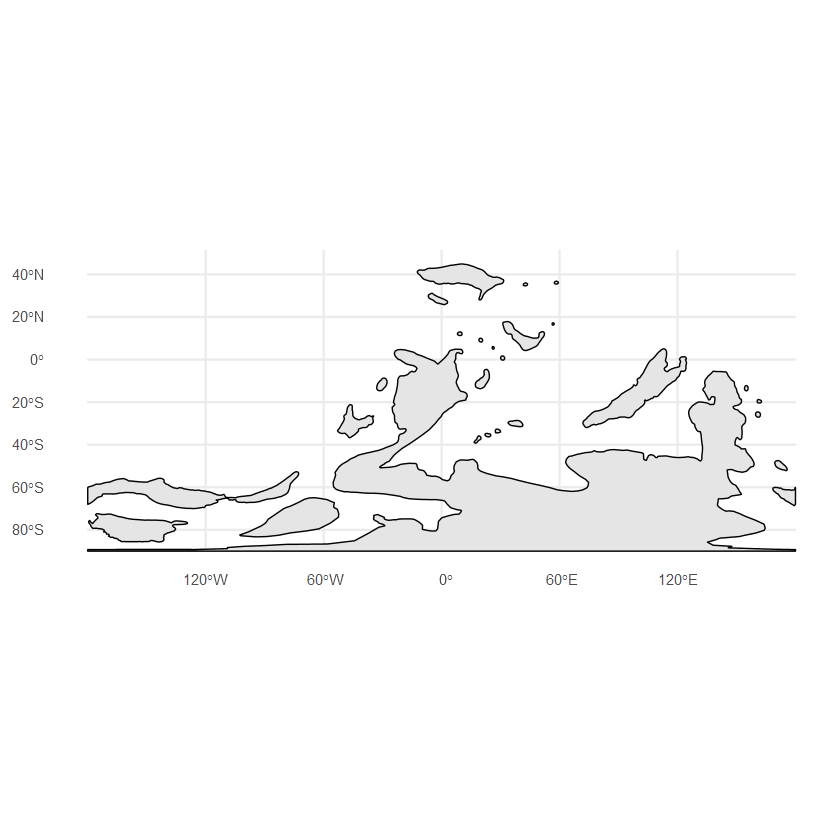

In [51]:
#| include: false
ggplot() +
  # geom_sf(data = plates.pt, fill = "gray90", color = "black", size = 0.3) +
# geom_sf(data = points_sf, aes(color = phylum), size = 1, alpha = 0.7) +
  geom_sf(data = coast_sf, fill = "gray90", color = "black", size = 0.3) +
  coord_sf() +
  theme_minimal() +
  labs()


The plate reconstruction is assigned to `plates.pt` by default is
rectangular.To overlay points you need to transform the data into a
shapefile object by passing the projection to `sf st_transform`. Change
the projection by transforming both the rectangular and points to a new
projection (ESRI 54030 is Robinson)

Sometimes the paleolng and paleolat values that are downloaded don't correspond to the same values as those in the viewer on PBDB. I don't have a reason for this so I find it safe to just reconstruct everything using the same plate model and then cross check against what it looks like in PBDB viewer. 

In [52]:

#convert dataframe to sf object 
points_sf <- pbdb.2stage %>%
  filter(!is.na(paleolng) & !is.na(paleolat)) %>%
  st_as_sf(coords = c("paleolng", "paleolat"), crs = 4326)

#transform it to projection, here rectagular Devonian 
points_sf <- sf::st_transform(points_sf, crs = st_crs(plates.pt))

# Transform plate boundaries to Robinson projection
platesRob <- sf::st_transform(plates.pt, "ESRI:54030")
coastRob <- sf::st_transform(coast_sf , crs = "ESRI:54030")
pointsRob <- sf::st_transform(points_sf, crs = "ESRI:54030")

cat("The latitudinal range of the reconstructed coordinates is:",range(pbdb.2stage$paleolat, na.rm = TRUE))


The latitudinal range of the reconstructed coordinates is: -60.6 39.19

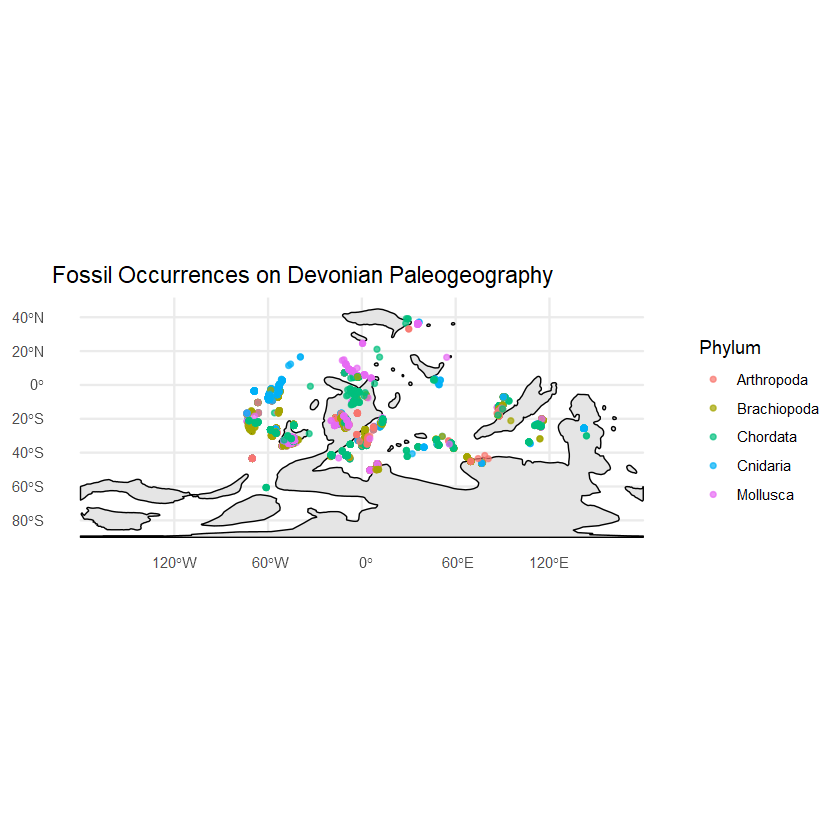

In [53]:
ggplot() +
  geom_sf(data = coast_sf, fill = "gray90", color = "black", size = 0.3) +
  geom_sf(data = pointsRob, aes(color = phylum), size = 1, alpha = 0.7) +
  coord_sf(crs = st_crs(coast_sf)) +
  theme_minimal() +
  labs(
    title = "Fossil Occurrences on Devonian Paleogeography",
    color = "Phylum"
  )

**Figure 2:** The Late Devonian (370 Ma)
[@scotesePALEOMAPPaleodigitalElevation2018] plate reconstruction on a
Robinson projection with coastlines and Frasnian marine fossil
occurrence data colored by phylum. After reconstructing I click cross-check the paleocoordinates via its occurrence number on PBDB.

In [54]:
#| include: false
# ggsave("../figures/Frasnian_point_occs.png", plot = ext_occs, dpi = 300, width = 6, height = 4, bg = "transparent")


## Regrided Geographic Coordinates to Equal Area Projection

The globe is divided into a grid of equal-area icosahedral hexagonal
cells using the `hexagrid()` function in `icosa`. In
`hexagrid(deg = x)`, is roughly equivalent to longitudinal degrees, so
that a degree of 1 is roughly equal to 111 km. This selects a
tessellation vector, which translates to the amount of area you select
for each cell. In our specified grid, each cell is roughly 629,000 km^2^
and results in a grid of 812 cells.

Set up hexagrid and enrich occurrence data frame with cell IDs
corresponding to paleolat/long of each entry. Summarize occurrences per
cell and add to `hexa_sf` for plotting.


In [55]:
hexa <- hexagrid(deg = 4.5, sf = TRUE)
hexa_sf <- hexa@sf
head(hexa_sf)


Selecting hexagrid with tessellation vector: c(3, 3).
Mean edge length: 4.439 degrees.



,geometry,faces
,<MULTIPOLYGON [°]>,<chr>
F1,MULTIPOLYGON (((-54 86.1945...,F1
F2,MULTIPOLYGON (((-126 86.046...,F2
F3,MULTIPOLYGON (((-54 86.1945...,F3
F4,MULTIPOLYGON (((-54 86.1945...,F4
F5,MULTIPOLYGON (((90 86.19451...,F5
F6,MULTIPOLYGON (((90 86.19451...,F6


null device 
          1

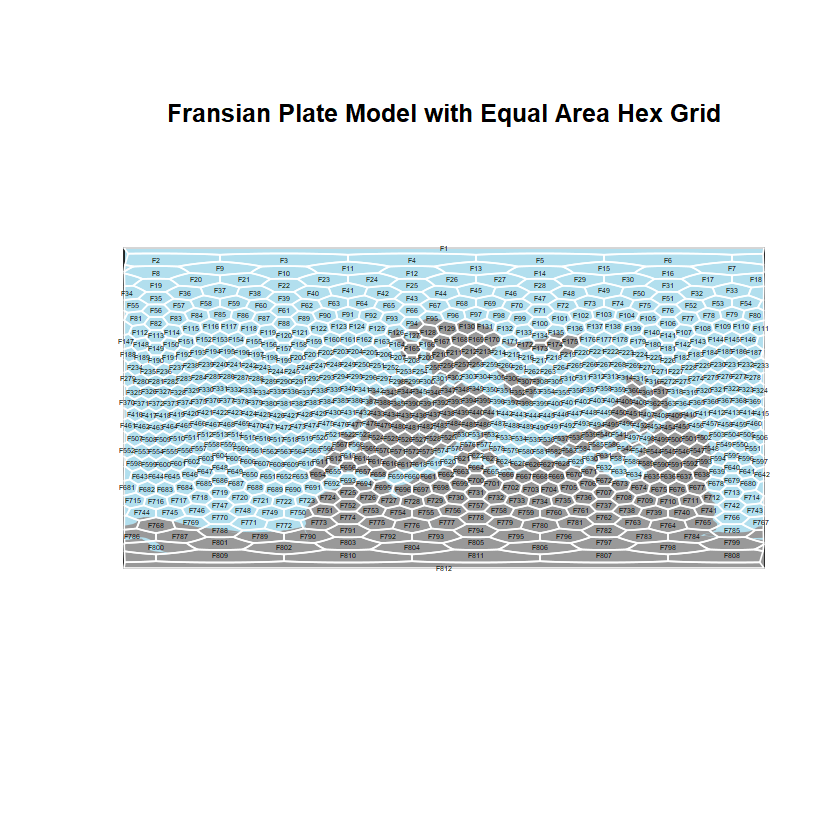

In [56]:
# using base R, will demonstrate how to plot with ggplot later

# Plot layers
plot(edge, col = "lightblue2", )
title(main = "Fransian Plate Model with Equal Area Hex Grid", line = -1)
plot(plates.pt$geometry, col = "gray60", border = NA, add = TRUE)
plot(hexa, border = "white", add = TRUE)
gridlabs(hexa, cex = 0.3)

# Close and save the PNG file
dev.off()


**Figure 4 :** Late Devonian (370Ma) reconstruction reprojected to equal
area icosahedral hexagonal grid

Flag cells that have less than 10 occurrences per [@alroy2018].

In [57]:
coords <- as.matrix(pbdb.2stage[, c("paleolng", "paleolat")])
pbdb.2stage$cell <- locate(hexa, coords)# use locate from icosa. second argument must be a matrix

# Get counts without altering pbdb.2stage
stage_counts <- cell_summary(pbdb.2stage, hexa, min_occ = 9)
#stage_counts <- cell_summary(pbdb.2stage, hexa, min_occ = NULL, min_collections = 9)


#add an occurrence column to hexa_sf that includes only those in stage_counts (e.g., has at least 10), all non matching cells will be NA

hexa_sf <- hexa_sf|>left_join(stage_counts|>select(cell, occurrences), by = c("faces" ="cell"))


The cells that were flagged are:
 [1] "F170" "F214" "F256" "F257" "F296" "F303" "F308" "F341" "F391" "F393"
[11] "F399" "F434" "F484" "F575" "F586" "F589" "F593" "F611" "F616" "F665"
[21] "F697" "F701" "F774"


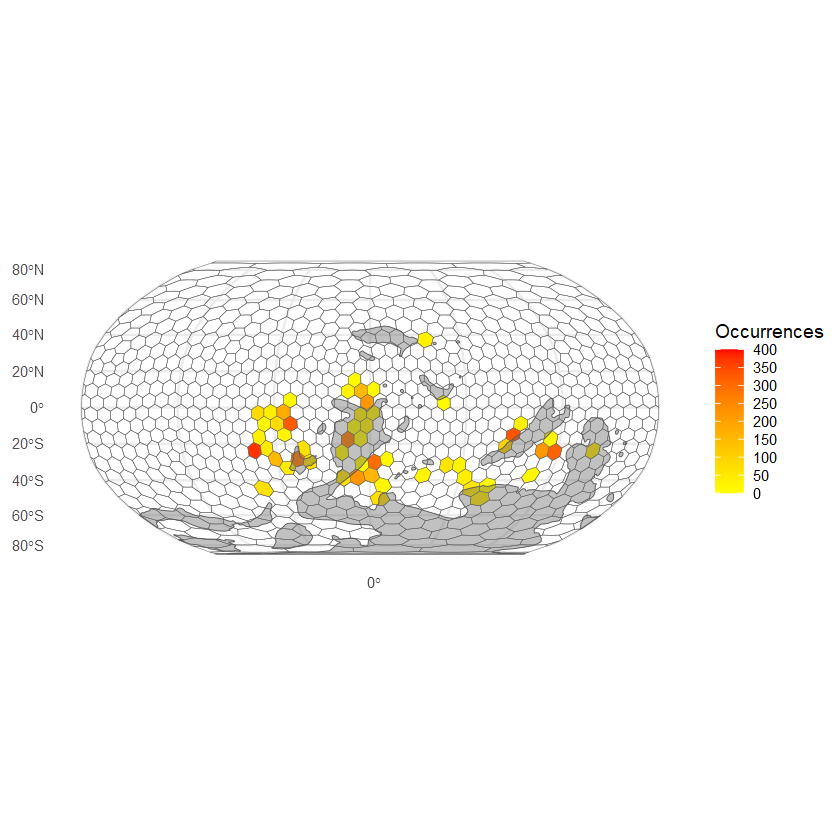

In [58]:
# Transform hexa_sf to same projection

hexa_sf <- sf::st_transform(hexa_sf, crs = "ESRI:54030")
frasnian_occ_no_bin <- ggplot() +


  geom_sf(data = hexa_sf, aes(fill = occurrences), size = 0.1) +
  geom_sf(data = coast_sf, fill = scales::alpha("gray40", 0.4))+
 
  
  scale_fill_gradient(low = "yellow", high = "red",
                      breaks = seq(0, 400, 50),
                      limits = c(0, 400),
                      name = "Occurrences",
                      na.value = scales::alpha("white", 0))+

  labs(#title = "Frasnian Occurrences by Hex Cell", 
       fill = "Occurrences") +
  theme_minimal()


frasnian_occ_no_bin


**Figure 5:** Fransian marine fossil occurrence frequency per grid cell if threshold filter applied.


Filter out cells from occurrence data frame that were flagged as having
\< 10 occurrences. I am not filtering out these cells at this stage because it is accounted for in the subsampling rountine (below) and is otherwise redundant. 

In [59]:
#| include: false
# ggsave("../figures/frasnian_occ_no_bin.png", plot = frasnian_occ_no_bin, width = 8, height = 6, dpi = 300)


In [60]:
#ifyou choosed to update pbdb.2stage to remove occurences thathave cells corresponding to stage_counts min_occ < 10. 

# pbdb.final <- semi_join(pbdb.2stage, stage_counts, by = "cell")


#make a final na drop

pbdb.final<-pbdb.2stage %>% filter(!is.na(paleolat))

cat("The number of occurrences that belong to the stage interval is now:", nrow(pbdb.final ),"\n")

cat("The number of unique genera globally is now:", length(unique(pbdb.final$genus)), "\n")

cat("The latitudinal range of the reconstructed coordinates is:",range(pbdb.final$paleolat, na.rm = TRUE))


The number of occurrences that belong to the stage interval is now: 8075 
The number of unique genera globally is now: 612 
The latitudinal range of the reconstructed coordinates is: -60.6 39.19

# Extinction Selectivity by Latitude bin

In this section, we bin all occurrences into latitude (10 degree bins)
bands and remove duplicate taxon occurrences from bands.

## Latitude Binning

This chunk utilizes a custom function `filter_bin` for latitudinal
bining of the data into latitude bins of desired degrees. It adds a
column for the latitude bin its in which is the column utilized by the
`calc_extinction` function (rather than abolute paleolatitude). 

\***Note:** The subsampling routine (Standardization Routine) in
`divvy:bandit` uses an equal-area rectangular grid to sample
occurrences. We chose this approach over a hexagonal grid because the
latitudinal binning procedure can cut through icosahedral cells. As a
result, icosahedral grids were used in our analysis only for
visualization.

In other contexts, however, a different standardization approach---such
as circular subsampling from divvy---might justify using a hexagonal
grid. To apply icosahedral grids for spatial sampling, one can extract the
center of each cell. In this setup, each hexagon center represents a
single site with all its occurrences aggregated to that point. While
possible, this method further reduce data size is recommended only when
spatial coverage is sufficiently dense. Here, obtaining cell centers is
shown as a demonstration rather than a primary analytical choice.


In [61]:

lat_bins <- seq(-100, 100, by = 10)

stage_bin_list <- map2(lat_bins, lat_bins + 10, ~ filter_bin(pbdb.final, .x, .y, .x + 5))
stage_bin <- bind_rows(stage_bin_list)


After binning the data, the cells in Other Data Exploration section can
be run.

To avoid artificially inflating frequencies of taxa with multiple
locations within a band during subsampling, this function ensures that
each genus appears only once per grid cell, while preserving the total
number of unique genera globally. The check below confirms that this
operation was successful.


In [62]:
# Confirm row count
cat("The new number of occurrences is:", nrow(stage_bin), "\n")
cat("The number of unique genera globally is now:", length(unique(stage_bin$genus)), "\n")
#check global number of unqiue genera should be the same before binning
if (length(unique(stage_bin$genus)) == length(unique(pbdb.final$genus))) {
  print("Occurrences successfully binned")
} else {
  print("Something went wrong")
}



The new number of occurrences is: 1160 
The number of unique genera globally is now: 612 
[1] "Occurrences successfully binned"


The new latbin column is the midpoint of the 10 degree latitude bin. For
example, the first entry in the table above has a paleo_lat of -50.3 °,
putting it in the -50 to -60 degree latitude bin, with a midpoint of -55
°.


Visualize how binning reduced the data spatially

In [63]:
#calculate new hexa_cell occurences after dropping duplicate taxon occs ber latitude band

bin_counts <- stage_bin %>%
  group_by(cell) %>%
  summarise(occurrences = n(), .groups = "drop") %>%
  filter(occurrences >= 9)  #repeat above filtering because not carrying through for some reason

hexa_bin <- hexa_sf %>%
  left_join(bin_counts, by = c("faces" = "cell"))


#save final dataset used for analysis
# write.csv(pbdb.final , "../data_files/fossil_occs_datafiles/cleaned_binned_occs_allphyla.csv")

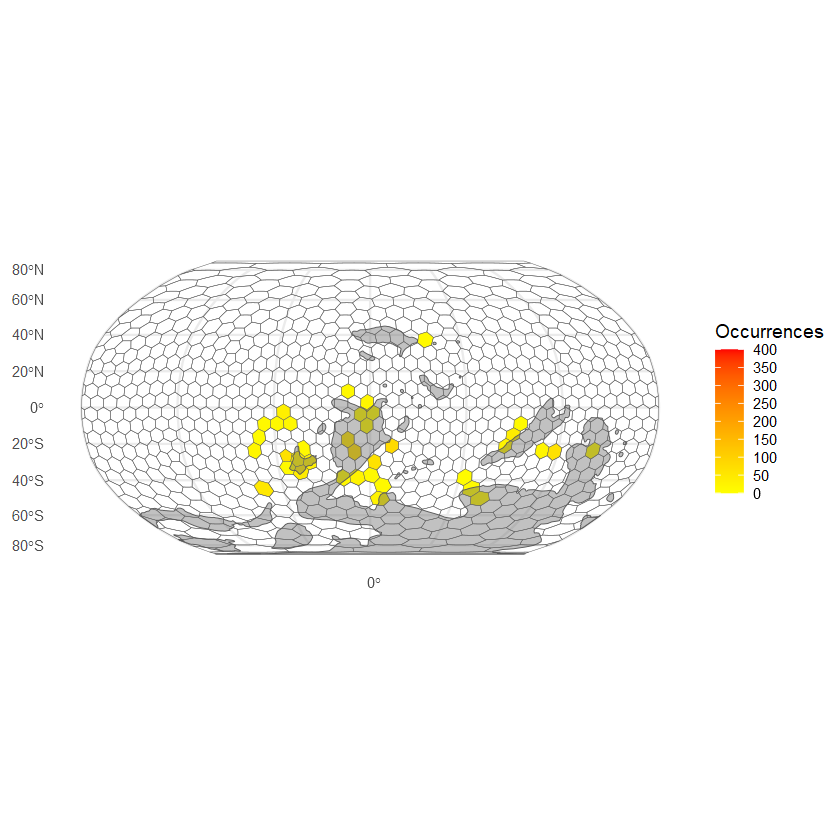

In [64]:
frasnian_occ_bin <- ggplot() +


  geom_sf(data = hexa_bin, aes(fill = occurrences.y), size = 0.1) +
  geom_sf(data = coast_sf, fill = scales::alpha("gray40", 0.4))+
 
  
  scale_fill_gradient(low = "yellow", high = "red",
                      breaks = seq(0, 400, 50),
                      limits = c(0, 400),
                      name = "Occurrences",
                      na.value = scales::alpha("white", 0))+

  labs(#title = "Frasnian Occurrences by Hex Cell after Binning", 
       fill = "Occurrences") +
  theme_minimal()


frasnian_occ_bin


**Figure 6:** Fransian marine fossil occurrence frequency per grid cell
after binning and keeping only one unique genera per lat bin.


In [65]:
#| include: false
# ggsave("../figures/frasnian_occ_bin.png", plot = frasnian_occ_bin, width = 8, height = 6, dpi = 300)


Inspect the taxonomic composition of each latitude bin

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
"Removed 5 rows containing non-finite outside the scale range (`stat_count()`)."


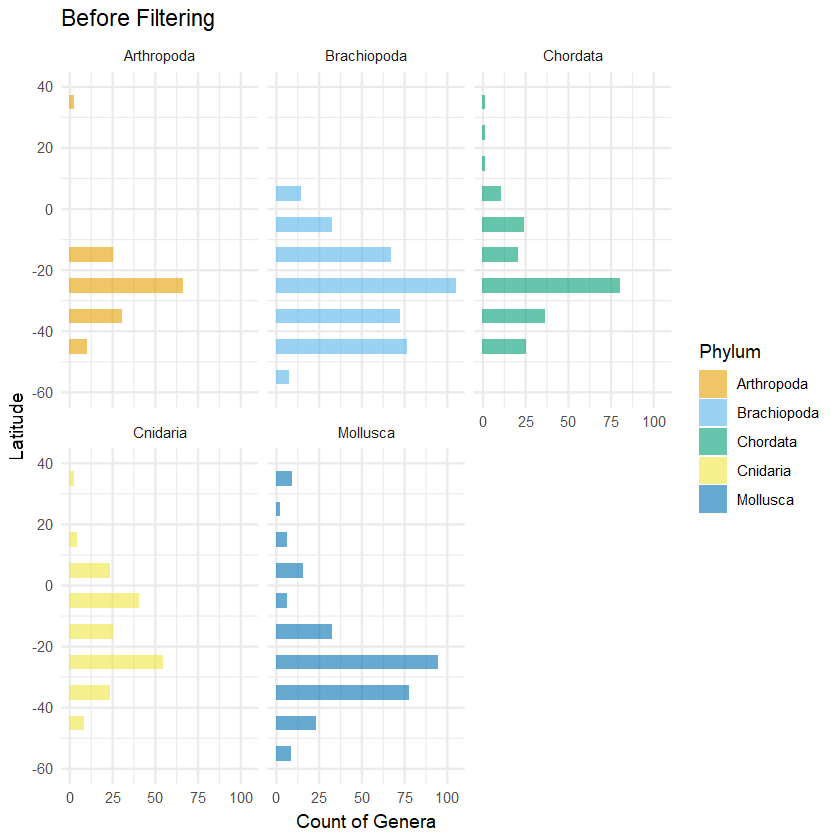

In [66]:

phylum<- c("Arthropoda", "Brachiopoda","Chordata","Cnidaria","Mollusca")

 before_filter<-ggplot() +  
  geom_bar(data = stage_bin, 
           aes(x = latbin, fill = phylum), 
           position = "stack", stat = "count", alpha = 0.6) + 
  scale_fill_manual(values = setNames(okabe_ito_10, phylum))+
  
  coord_flip() +  
  scale_x_continuous(breaks = seq(40, -60, by = -5)) +
  xlim(-60,40)+
  labs(title = "Before Filtering",
       x = "Latitude",
       y = "Count of Genera",
       fill = "Phylum") +
  
  theme_minimal()+
facet_wrap(~ phylum)
 
before_filter

# ggsave("../figures/lat_tax_composition.png", plot = lat_tax_comp, width = 10, height = 6, dpi = 300)


**Figure 5:** Frasnian marine phyla occurrences per latitude bin no threshold count filtering.


Some phyla have low counts of unique genera which are statitically
insufficeint and may create noise when estimating generic extinction per
latitude band after subsampling. Uncomment the threshold_count in the below block tofilter out low numbers of occurrences.


The number of occurrences is now: 1098 
 with  605 unique genera 


Warning message in geom_bar(data = filtered_stage_bin, aes(x = latbin, fill = phylum), :
"Ignoring unknown parameters: ``"
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


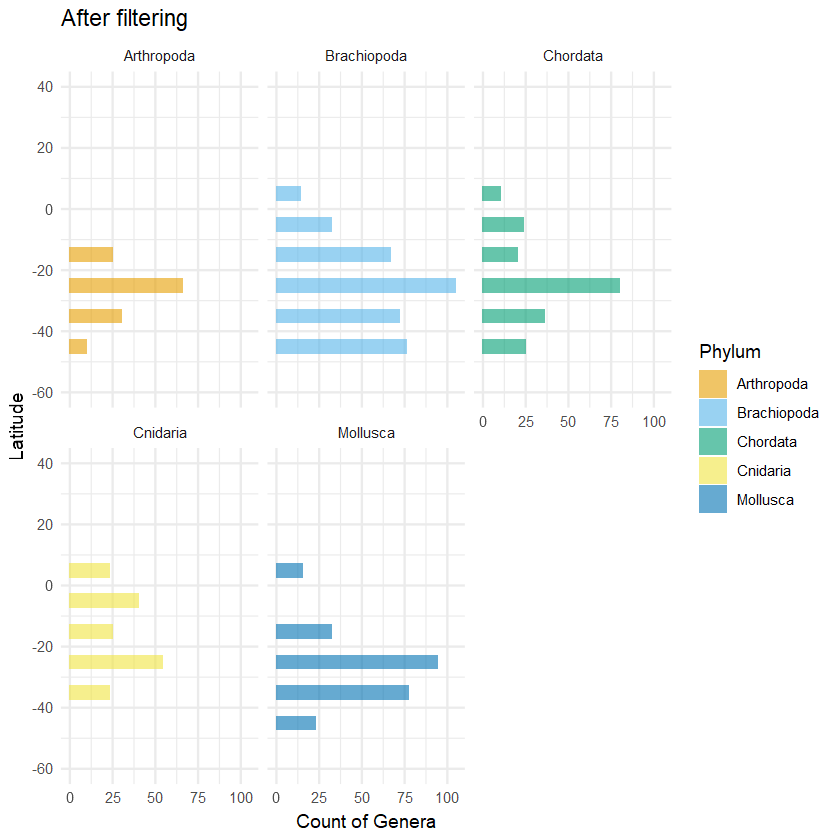

In [67]:
#make a copy
filtered_stage_bin <-stage_bin  

# cat("The number of occurrences was:", nrow(stage_bin),"\n","with ", length(unique(stage_bin$accepted_name)), "unique genera \n")
# 
# 
threshold_count<-10 #set the number of unique geneera a lat bin must contain of a specific phylum to include it.

filtered_stage_bin<-stage_bin%>%group_by(latbin,phylum)%>%filter(n_distinct(genus)>=threshold_count)%>%ungroup()


cat("The number of occurrences is now:", nrow(filtered_stage_bin),"\n","with ", length(unique(filtered_stage_bin$genus)), "unique genera \n")

 after_filter<-ggplot() +
  geom_bar(data = filtered_stage_bin,
           aes(x = latbin, fill = phylum),
           aes(x = latbin_shuf, fill = phylum),
           position = "stack", stat = "count", alpha = 0.6) +
scale_fill_manual(values = setNames(okabe_ito_10, phylum))+


  coord_flip() +
  scale_x_continuous(breaks = seq(40, -60, by = -5)) +
  xlim(-60,40)+
  labs(title = "After filtering",
       x = "Latitude",
       y = "Count of Genera",
       fill = "Phylum") +

  theme_minimal()+
facet_wrap(~ phylum)

after_filter


Warning message:
"Removed 5 rows containing non-finite outside the scale range (`stat_count()`)."


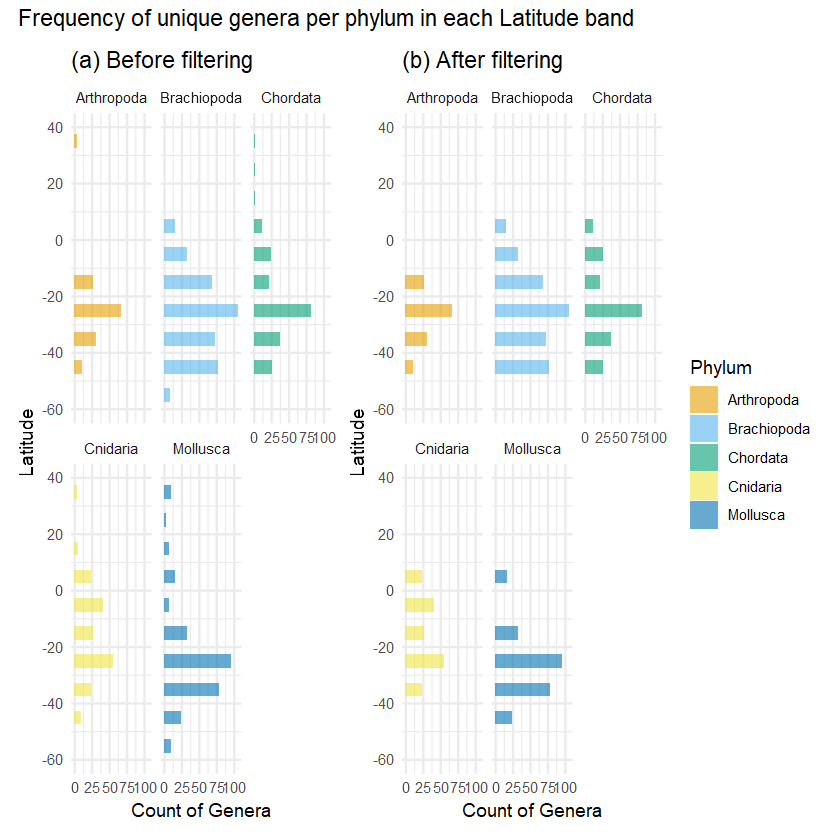

In [68]:
#| include: false
lat_tax_comp<- (before_filter + 
   ggtitle("(a) Before filtering")+
   theme(legend.position = "none"))+

(after_filter + 
   ggtitle("(b) After filtering"))+
  plot_annotation(title = "Frequency of unique genera per phylum in each Latitude band") &
  plot_layout(guides = "collect")+
  theme(legend.position = "right") 
lat_tax_comp

# ggsave("../figures/lat_tax_composition.png", plot = lat_tax_comp, width = 10, height = 6, dpi = 300)


Calculate the percent of unique genera in each cell that went extinct

Now we want to calculate the percent extinction in each latitude band
using the custom function `calc_extinction` which categorizes the data
based on wether a particular taxa went extinct (ex = 1) or did not (ex =
0) as assigned previously.


In [69]:
# #use custom function to calculate and assign to new output df

percent_extinct <- calc_extinction(filtered_stage_bin)

percent_extinct <- percent_extinct %>%
  filter(latbin >= -90, latbin <= 90) #select the range of bins

head(percent_extinct,5)

,latbin,num_extinct_genera,num_genera,percent
,<dbl>,<int>,<int>,<dbl>
1,-45,55,134,41
2,-35,74,238,31
3,-25,195,399,49
4,-15,49,169,29
5,-5,40,96,42


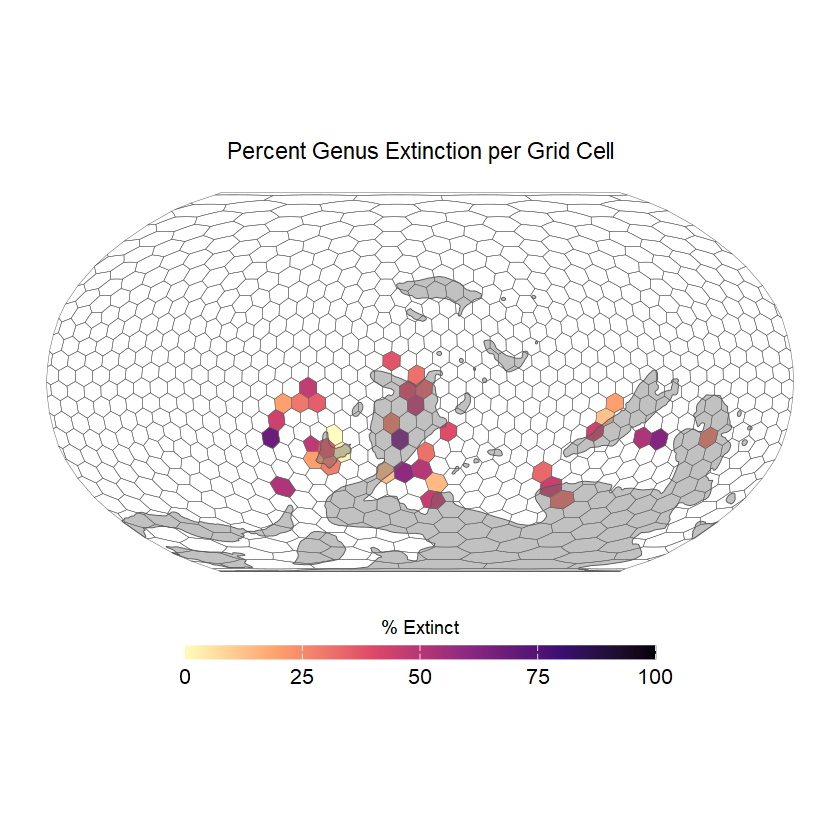

In [70]:
extinct_percents <- filtered_stage_bin %>%
  group_by(cell) %>% 
  summarize(
    n_total = n(),
    n_extinct = sum(ex),
    percent_extinct = 100 * n_extinct / n_total
  )%>%
filter(n_total >= 9)
# Convert to named numeric vector
extinction_vec <- extinct_percents$percent_extinct
#extinct_percents <- extinct_percents %>%  mutate(cell = paste0("F", as.character(cell)))


names(extinction_vec) <- extinct_percents$cell 

# Create full-length vector of 0s or NAs for all faces
extinction_plot_vals <- rep(NA, nrow(hexa_bin))

#Match and assign values where available
matched_indices <- match(hexa_bin$faces, names(extinction_vec))
extinction_plot_vals[!is.na(matched_indices)] <- extinction_vec[matched_indices[!is.na(matched_indices)]]

#Add to sf object
hexa_bin$percent_extinct <- extinction_plot_vals

extinction_colors <- rev(viridis(6, option = "A"))


frasnian_extinct_plot <- ggplot() +
  geom_sf(data = hexa_bin, aes(fill = percent_extinct), size = 0.1) +
  geom_sf(data = coast_sf, fill = scales::alpha("gray40", 0.4)) +
  scale_fill_gradientn(
    colors = extinction_colors,
    limits = c(0, 100),
    breaks = c(0, 25, 50, 75, 100),
    name = "% Extinct",
    na.value = "transparent"
  ) +
  labs(title = "Percent Genus Extinction per Grid Cell",
    fill = "% Extinct") +
  theme_minimal()+
  theme(panel.border = element_blank(),
    plot.background = element_blank(),
    legend.position = "bottom",
    # legend.position = "none",
    legend.title.position = "top",
    legend.title.align = 0.5,
    legend.key.spacing.x = unit(10, "pt"), 
    legend.key.width = unit(2, "cm"),
    legend.key.height = unit(0.3, "cm"),
    legend.text = element_text(size= 12),
    plot.title = element_text(hjust = 0.5),
    legend.box = "vertical",
    axis.text = element_blank(),           
    axis.ticks = element_blank(),          
    panel.grid = element_blank())          

frasnian_extinct_plot


**Figure 6:** Percent genus extinction of cells after removing duplicate
taxa occurrences.


In [71]:
#| include: false
# ggsave("../figures/hexagrid_extinct.png",
#        plot = frasnian_extinct_plot,
#        width = 5,
#        height = 4,
#        units = "in",
#        dpi = 300,
#        bg = "transparent")


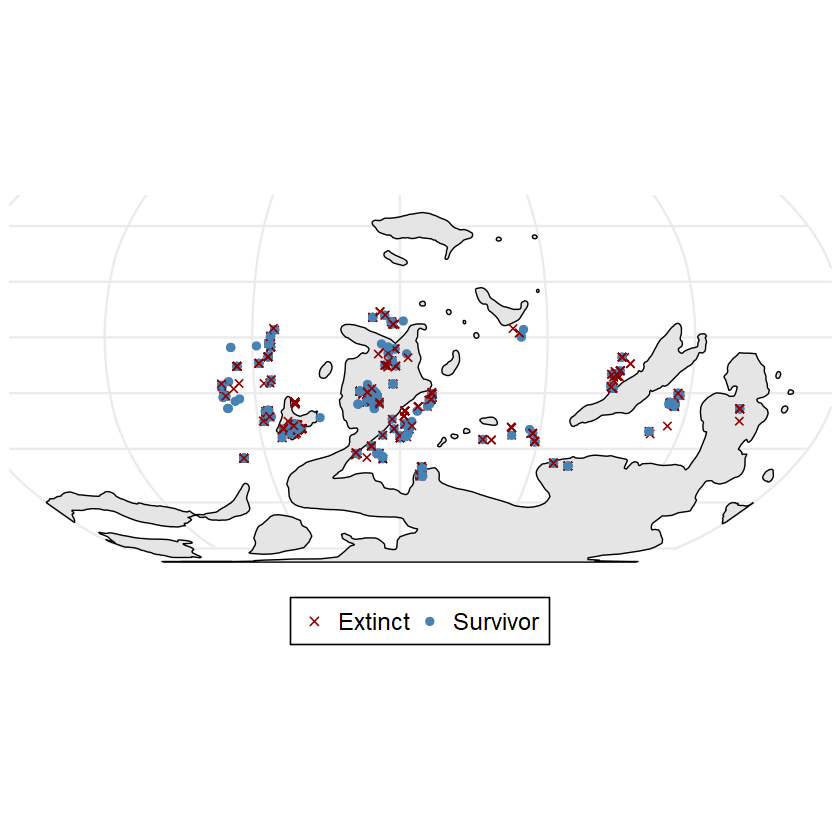

In [72]:
#convert dataframe to sf object 
points_sf_reduced <- filtered_stage_bin %>%
  filter(!is.na(paleolng) & !is.na(paleolat)) %>%
  st_as_sf(coords = c("paleolng", "paleolat"), crs = 4326)


points_sf_reduced <- sf::st_transform(points_sf_reduced, crs = st_crs(plates.pt))

pointsRob <- sf::st_transform(points_sf_reduced, crs = "ESRI:54030")

ext_occs <- ggplot() +
  geom_sf(data = coastRob, fill = "gray90", color = "black", size = 0.3) +
  geom_sf(
    data = pointsRob,
    aes(color = factor(ex), shape = factor(ex)),
    size = 2,
    alpha = 1
  ) +
  scale_color_manual(
    values = c("0" = "darkred", "1" = "steelblue"),
    labels = c("Extinct", "Survivor")
  ) +
  scale_shape_manual(
    values = c("0" = 4, "1" = 16
               ),
    labels = c("Extinct", "Survivor")
  ) +
  coord_sf(crs = st_crs(platesRob)) +
  theme_minimal() +
theme(
  axis.text.x = element_blank(),
  axis.text.y = element_blank(),
  legend.position = "bottom",
  legend.spacing.y = unit(0.1, "mm"),
  legend.title = element_blank(),
  legend.text = element_text(size = 14),
  # panel.grid.major = element_blank(),
  panel.grid.minor = element_blank(),
  legend.background = element_blank(),
  legend.box.background = element_rect(colour = "black")
)


print(ext_occs)


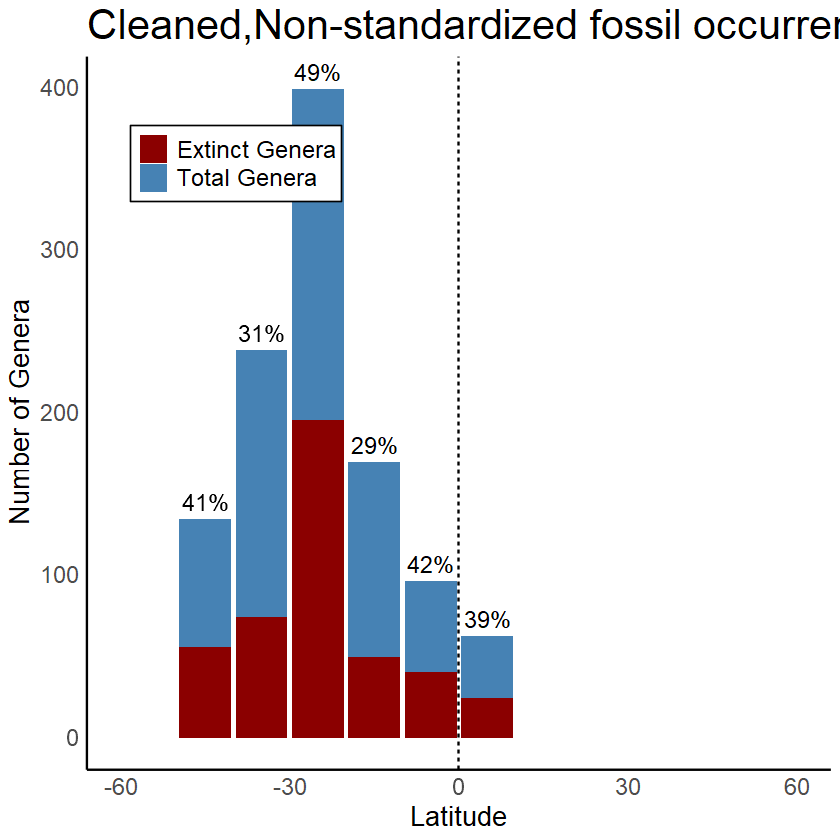

In [73]:
#add percent extinct to plot
stacked_extinct_genera <- ggplot() + 
  geom_col(data = percent_extinct, aes(x = latbin, y = num_genera, fill = "Total Genera")) +
  geom_col(data = percent_extinct, aes(x = latbin, y = num_extinct_genera, fill = "Extinct Genera")) + 
  labs(title = "Cleaned,Non-standardized fossil occurrences",
    x = "Latitude", y = "Number of Genera") +
  scale_fill_manual(values = c("Total Genera" = "steelblue", "Extinct Genera" = "darkred")) + 
  geom_text(data = percent_extinct, aes(x = latbin, y = num_genera, label = paste0(round(percent, 2), "%")),
            vjust = -0.5, size = 5) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  coord_cartesian(xlim = c(-60, 60)) +
  theme_minimal() +
  theme(axis.line = element_line(color = "black", linewidth = 0.5),
    legend.title = element_blank(),
    legend.position = c(0.2, 0.85),
    legend.text = element_text(size = 14),
    title = element_text(size = 20),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    legend.box.background = element_rect(color = "black", fill = "white"),
    axis.text.x = element_text(size = 14),
    axis.text.y = element_text(size = 14),

    axis.title.x = element_text(size = 16),
    axis.title.y = element_text(size = 16)
  )

stacked_extinct_genera


**Figure 7:** Stacked bar chart of the number of unique genera that went
extinct (red) out of the total global number of unique genera (blue) per
latitude band


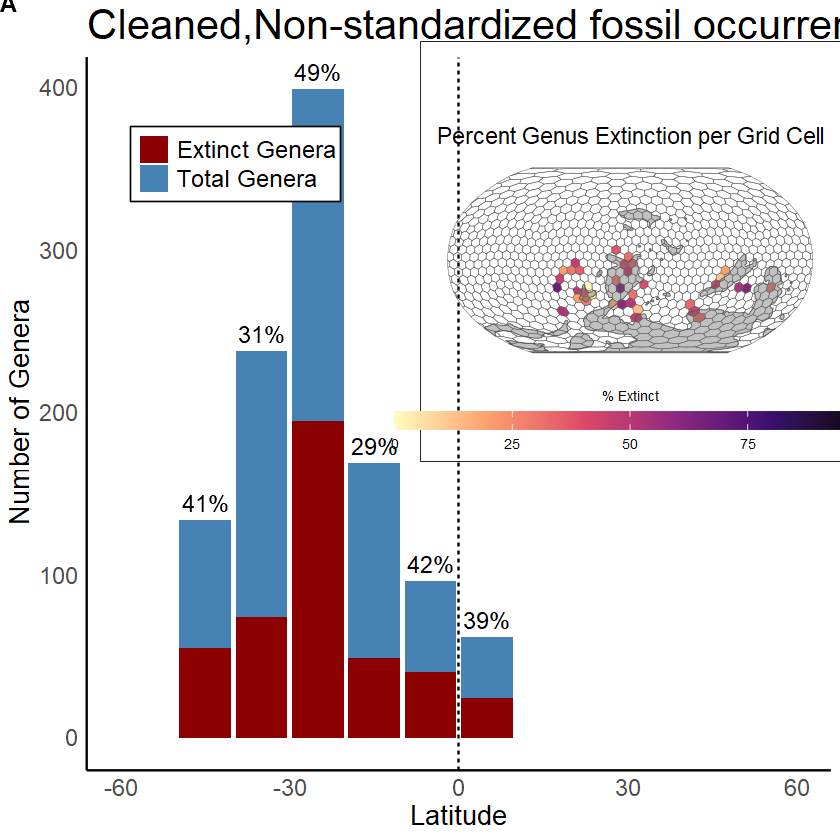

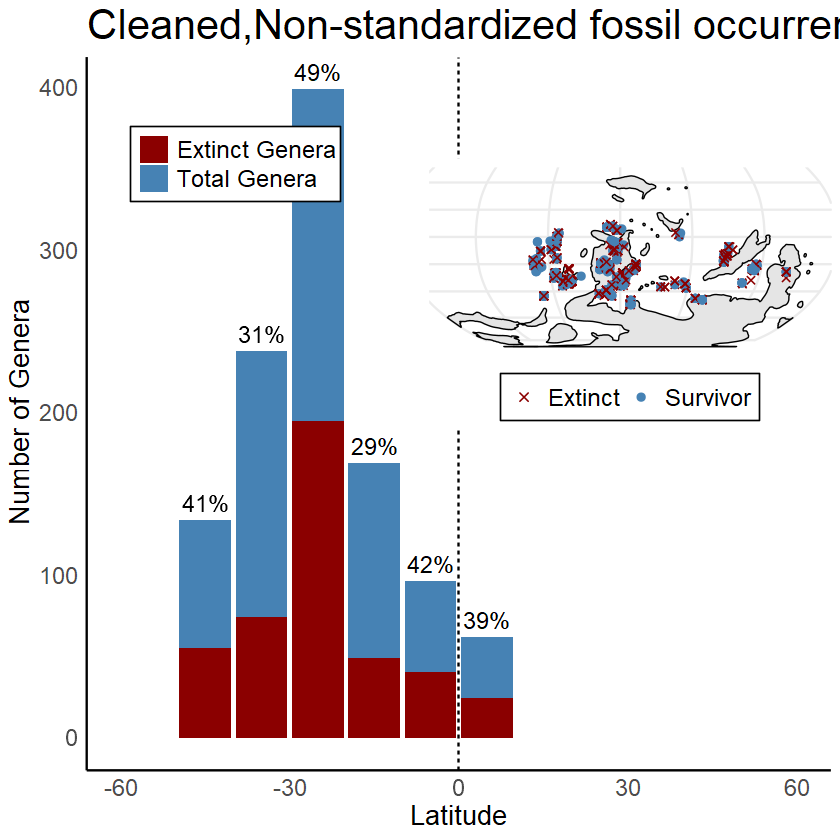

In [74]:
#|include: false
library("grid")
library("cowplot")
# ggsave("../figures/kw_generic_extinction_nothres_10degbin_alltxa.png", plot = stacked_extinct_genera, width = 8, height = 6, dpi = 300)
frasnian_extinct_plot_small_legend <- frasnian_extinct_plot +
  theme(
    legend.key.height = unit(0.4, "cm"),
    legend.text = element_text(size = 8),
    legend.title = element_text(size = 8))
    
rect <- rectGrob(
  x = 0.5, y = 0.45,          # bottom-left corner
  width = 0.5, height = 0.5, # same size as inset
  just = c("left", "bottom"), # anchor at bottom-left
  gp = gpar(fill = NA, col = "black", lwd = 0.5)
)

p <- ggdraw(stacked_extinct_genera) +
  draw_grob(rect)+
  draw_plot(frasnian_extinct_plot_small_legend, .5, .4, .50, .5)+labs(tag = "A")
  
p


q <-ggdraw(stacked_extinct_genera) + draw_plot(ext_occs, .5, .4, .50, .5)

  
q 
# ggsave("../figures/kw_generic_extinction_10degbin_allphyla.png", plot = q, width = 8, height = 6, dpi = 300)

**Figure 3:** The Late Devonian (370 Ma)
[@scotesePALEOMAPPaleodigitalElevation2018] plate reconstruction on a
Robinson projection with coastlines and Frasnian marine fossil
occurrence data colored by survivorship


# Standardization Routine

Fossil occurrence data were spatially subsampled using the
[`divvy`](https://gawainantell.github.io/divvy/index.html) package
[@antell2024], which implements equal-area rectangular grids to
standardize spatial sampling and reduce geographic sampling bias. The
function `divvy:uniquify` removes duplicate occurrences, however, this
was performed above when the data was binned and is redundant to repeat.


## Subsampling by equal latitude bands

In [75]:
rWorld <- rast()
prj <- 'EPSG:8857'
rPrj <- project(rWorld, prj, res = 200000) # 200,000m is approximately 2 degrees

# coordinate column names for the current and target coordinate reference system
xyCartes <- c('paleolng','paleolat')

#xyCartes <- c('hexa_long','hexa_lat') # if want to use hexagrid instead

xyCell   <- c('centroidX','centroidY')

# project occurrences and retrieve cell centroids in new coordinate system
llOccs <- vect(filtered_stage_bin, geom = xyCartes, crs = 'epsg:4326')
prjOccs <- project(llOccs, prj)
cellIds <- cells(rPrj, prjOccs)[,'cell']
filtered_stage_bin[, xyCell] <- xyFromCell(rPrj, cellIds)

filtered_stage_bin <- as.data.frame(filtered_stage_bin) # ensure it is a dataframe 


Verify your data structure again using `divvy:sdSumry` before and after
subsampling.

In [76]:
# make sure the procedure did not truncate the data, should maintain nTax and nOcc if worked properly. 
un_samp_summary <- sdSumry(filtered_stage_bin, 
                        taxVar =    'genus', 
                        #collections = 'collection_no',
                        xy = xyCell, 
                        
                        crs = prj)

un_samp_summary 


nOcc,nLoc,centroidX,centroidY,latRange,greatCircDist,meanPairDist,minSpanTree,SCOR,nTax
1093,144,225485.4,-2750838,59.63062,20035.97,6173.653,64562.05,7.658149,604


You should now have `cellX` and `cellY` columns which are in meters from
some point on the projection. These `cellX` and `cellY` values can be
supplied to `divvy:bandit`.


In [77]:
set.seed(11)
bandAbs <- bandit(dat = filtered_stage_bin, xy = xyCell,
                  iter = 1000, nSite = 6, output = 'full',
                  bin = 10, absLat = FALSE,
                  crs = prj
)

# head(bandAbs[[1]])

In [78]:
#This can take a while so it was saved as an Rdata(rds) file and called here instead 
# sampsMeta <- sdSumry(dat = bandAbs, 
#                      taxVar = 'accepted_name',
#   
#                      xy = xyCell,
#                      crs = prj
#                      )
# saveRDS(sampsMeta, 'data_files/sampsMeta.rds')

#sampsMeta<-readRDS('data_files/sampsMeta.rds')


# Reconstruct Latitudinal Extinction

Take the subsampled data stored in `bandAbs` and apply `calc_extinction`
custom function.



In [79]:
subsampled_extinction_lat<- purrr::map(bandAbs,~calc_extinction(.x))

## Interquartile Ranges for latitudinal binned extinction


Estimate error in sub-sampled latitudinal extinction percentages as
interquartile range. If you have very few points(e.g., <50) for a band
the IQR calculation may be misleading. Ensure you have enough iterations
in `divvy:bandit` to have at least a recommended 50 occurrences per
*latbin*.


In [80]:
# Initialize empty vectors
latbin <- character()
percent_extinction <- numeric()

# Loop through each data frame in the list
for (i in seq_along(subsampled_extinction_lat)) {
  df <- subsampled_extinction_lat[[i]]  # Extract the current data frame
  
  # Append values from columns
  #binned_lat <- c(binned_lat, df$lat_binned)
  latbin <- c(latbin, df$latbin)
  
  unique(latbin)
  percent_extinction <- c(percent_extinction, df$percent)
}

# Create a new data frame, save dataframe for statistical comparision of gradients
df_combined <- data.frame(latbin= latbin, percent_extinction = percent_extinction)

head(df_combined, 5)

cat("The number of points per latbin:")
print(table(df_combined$latbin))


# write.csv(df_combined , "../data_files/fossil_occs_datafiles/latin_ext.csv")

,latbin,percent_extinction
,<chr>,<dbl>
1,-45,33
2,-45,32
3,-45,40
4,-45,46
5,-45,43


The number of points per latbin:
 -15  -25  -35  -45   -5    5 
1664 1245 1000 1000  999 1271 


In [81]:
band_combined <- df_combined# %>% filter(latbin != "-50") # if there is a band missing it may throw an error. Remove problematic bins as such

iqr_results <- band_combined %>%
  mutate(latbin = as.numeric(latbin)) %>%  
  group_by(latbin) %>%
  summarise(
    median = median(percent_extinction, na.rm = TRUE),
    q1 = quantile(percent_extinction, 0.25, type = 5, na.rm = TRUE),
    q3 = quantile(percent_extinction, 0.75, type = 5, na.rm = TRUE),
    iqr = IQR(percent_extinction, na.rm = TRUE)
  ) %>%
  arrange(latbin)%>%
  filter(!near(iqr, 0))

iqr_results

# write.csv(iqr_results , "../data_files/fossil_occs_datafiles/iqr_results_MI.csv")

latbin,median,q1,q3,iqr
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-45,40,32.00,45.00,13.0
-35,33,26.00,41.00,15.0
-25,50,41.75,53.00,11.0
-15,26,21.00,35.00,14.0
-5,41,32.00,50.00,18.0
5,39,33.00,46.75,13.5


In [82]:
# band_combined <- band_combined %>%
#   mutate(latbin = as.numeric(as.character(latbin)))  # if latbin is factor or character

# band_combined <- bind_rows(
#   band_combined,
#   tibble(
#     latbin = 20,  
#     percent_extinction = NA,
#   )
# )

# band_combined <- band_combined %>%
#   mutate(latbin = factor(latbin, levels = sort(unique(latbin))))

#print(band_combined)


Warning message in geom_vline(xintercept = 0, linestyle = "dashed"):
"Ignoring unknown parameters: `linestyle`"
`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"Chernobyl! trL>n 6"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"Chernobyl! trL>n 6"
Warning message in sqrt(sum.squares/one.delta):
"NaNs produced"
Warning message:
"Using the `size` aesthetic with geom_path was deprecated in ggplot2 3.4.0.
ℹ Please use the `linewidth` aesthetic instead."


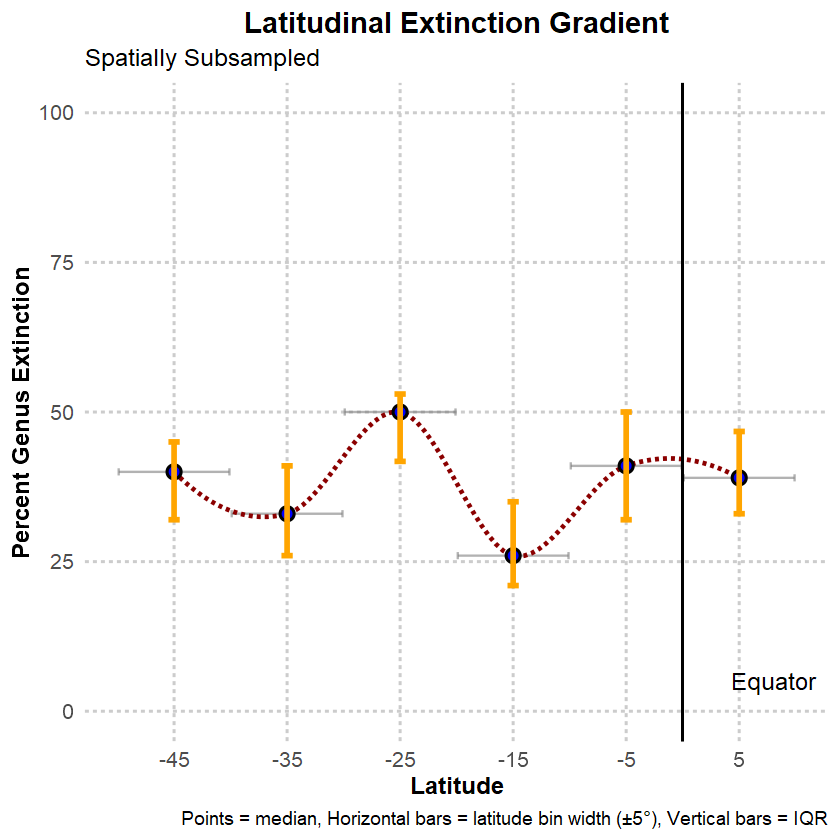

In [83]:
lat_extinct_grad_point <- ggplot(iqr_results, aes(x = latbin, y = median)) +
  
  # Horizontal bin width shows ±5 degrees (bin width = 10)
  ggstance::geom_errorbarh(aes(xmin = latbin - 4.9, xmax = latbin + 4.9), # so they don't overlap 
                 height = 1.2, color = "gray50", alpha = 0.6) +
  
  # Trend line
  geom_smooth(method = "loess", se = FALSE, color = "darkred", 
              linetype = "dashed", linewidth = 1) +  
  
  # Points,mean value
  geom_point(size = 3, shape = 21, fill = "blue", color = "black", stroke = 1) +
  
  # Vertical IQR error bars, plot on top
geom_errorbar(
  aes(x = latbin, ymin = q1, ymax = q3),
  width = 1.0, color = "orange", linewidth = 1.2
) +  
  ylim(0,100)+
  scale_x_continuous(breaks = seq(55, -55, by = -10)) +
  
  labs(
    title = "Latitudinal Extinction Gradient",
    subtitle = "Spatially Subsampled",
    caption = "Points = median, Horizontal bars = latitude bin width (±5°), Vertical bars = IQR",
    x = "Latitude",
    y = "Percent Genus Extinction"
  ) +
  geom_vline(xintercept = 0, linestyle = "dashed")+
  annotate("text",label = "Equator", x = 8, y = 5)+
  theme_minimal(base_size = 14) + 
  
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),  
    axis.text = element_text(size = 12),  
    axis.title = element_text(size = 14, face = "bold"),  
    panel.grid.major = element_line(color = "grey80", linetype = "dashed"),
    panel.grid.minor = element_blank()
  )
lat_extinct_grad_point

**Figure 8:** Median (blue dots) latitudinal extinction gradient binned
by ten degrees (grey bars). Dashed red line is loess smooth. Vertical
bars are interquartile range.

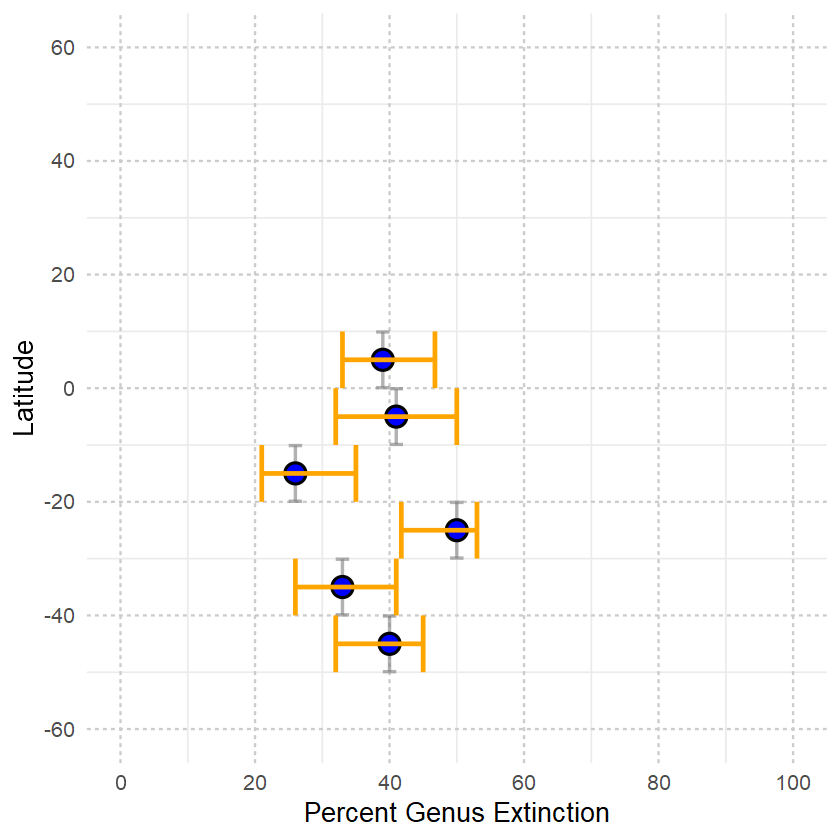

In [84]:
#| include: false
lat_extinct_grad_point <- ggplot(iqr_results, aes(x = median, y = latbin)) +
  
  # Vertical bin width: ±5° latitude range
  geom_errorbar(
    aes(ymin = latbin - 4.9, ymax = latbin + 4.9),
    width = 2, color = "gray50", alpha = 0.6
  ) +

  # Trend line (horizontal now)
 # geom_smooth(method = "loess", se = FALSE, color = "darkred", 
  #            linetype = "dashed", linewidth = 1) +  
  
  # Points
  geom_point(size = 5, shape = 21, fill = "blue", color = "black", stroke = 1) +

  # Horizontal IQR error bars
  ggstance::geom_errorbarh(
    aes(xmin = q1, xmax = q3),
    height = 10.0, color = "orange", size = 1
  ) +

  # Set axis limits
  scale_x_continuous(limits = c(0, 100), breaks = seq(0, 100, by = 20)) +
  scale_y_continuous(limits = c(-60, 60), breaks = seq(-60, 60, by = 20)) +

  labs(
    #title = "Latitudinal Extinction Gradient",
    #subtitle = "Closed Respiratory"
    
  ) +
labs(
    #title = "Latitudinal Extinction Gradient",
   # subtitle = "Spatially Subsampled: Closed system",
    #caption = "Points = median, Horizontal bars = IQR",
    x = "Percent Genus Extinction",
    y = "Latitude"
  )+
  theme_minimal(base_size = 16) +
  theme(
    #plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.text = element_text(size = 12),
    #axis.title = element_text(size = 14, face = "bold"),
    panel.grid.major = element_line(color = "grey80", linetype = "dashed", linewidth = 0.5)
  )

lat_extinct_grad_point

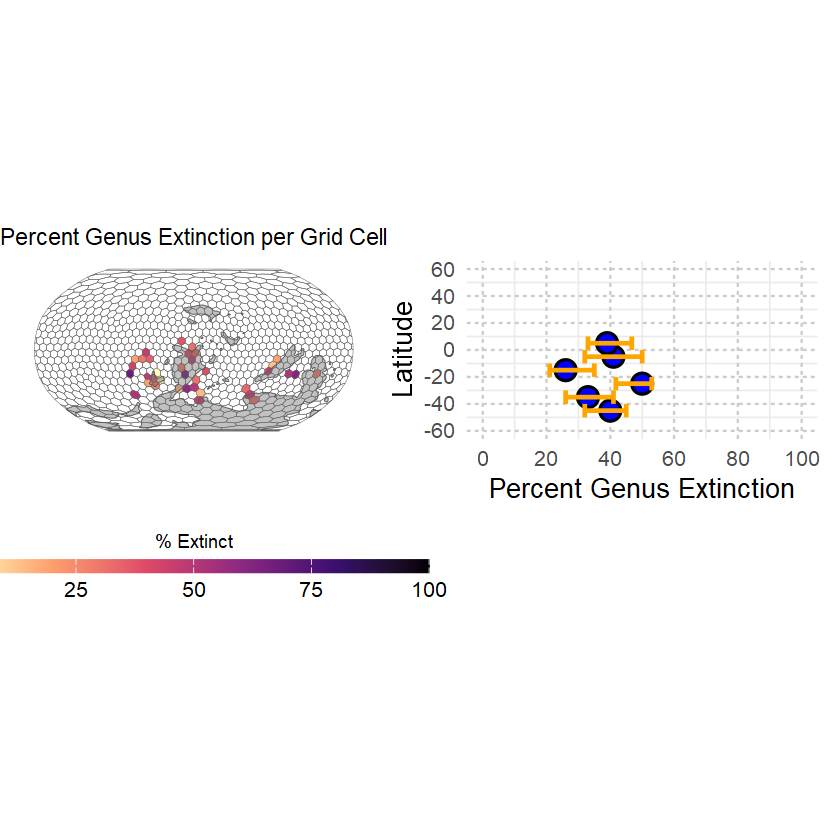

In [85]:
combo_plot<-frasnian_extinct_plot + lat_extinct_grad_point
combo_plot


**Figure 9:** Latitudinal Extinction Gradient plotted side-by-side with spatial exintction patterns.

In [86]:
#| include: false
# ggsave("../figures/tri_combo_plot_MI.png", plot = combo_plot, width = 10, height = 6, dpi = 300)

In [87]:
#| include: false
# ggsave("../figures/lat_extinct_grad_point_ribbon.png", plot = lat_extinct_grad_point_ribbon, width = 4, height = 6, dpi = 300)

# Expanded Data Exploration


Other visual analysis to aid either in interpretation or decision to
include/exclude potentially inadequate data.

The spatial distribution of different taxa will have a strong influence
on interpretation of extinction selectivity in certain latitude bands.

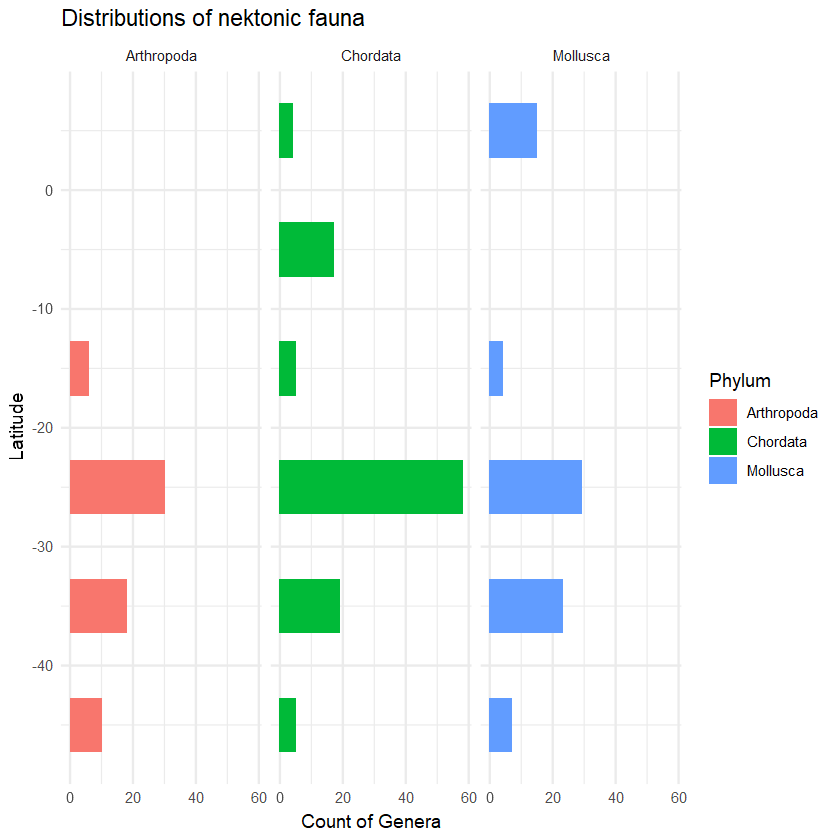

In [88]:
#filter the classes that existed during devonian that were nektonics
#colnames(stage_bin)
nektonic_classes <- c(
  # Chordata
  "Placodermi", "Acanthodii", "Chondrichthyes", "Osteichthyes",
  # Mollusca
  "Cephalopoda",
  # Arthropoda
  "Eurypterida", "Trilobita"
)

# Filter for nektonic classes from within your selected phyla
stage_bin_nektons <- filtered_stage_bin %>%
  filter(class %in% nektonic_classes)

cephalopods <- filtered_stage_bin%>% filter(class %in% nektonic_classes)

#length(unique(stage_bin_nektons$accepted_name))
nekton_dist<-ggplot(stage_bin_nektons, aes(x = latbin, fill = phylum)) +  
  geom_bar(show.legend = TRUE) +  
  coord_flip() +  
  labs(title = "Distributions of nektonic fauna",
       x = "Latitude",
       y = "Count of Genera",
       fill = "Phylum") +
  theme_minimal()+
facet_wrap(~ phylum)

nekton_dist

# ggsave("Figures/nekton_dist.png", plot = nekton_dist, width = 10, height = 6, dpi = 300)


**Figure 10:** (a) Distribution of nektonic fauna per latitude band.
Mobility is related to respiratory demand and may reveal underlying
patterns of extinction relative to change temperature and oxygen
conditions.


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


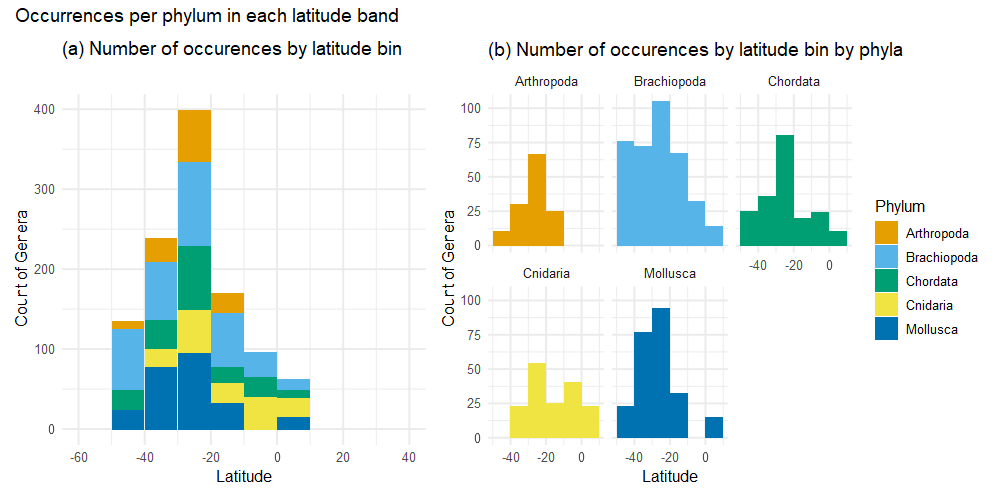

In [89]:

options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 100)

okabe_ito_10_minor <- c(
  "#E69F00", # orange
  "#56B4E9", # sky blue
  "#0072B2", # blue
  "#999999" # grey
)
num_occ_phyla <- filtered_stage_bin %>%
  count(latbin, phylum) %>%
  ggplot(aes(x = latbin, y = n, fill = phylum)) +
  scale_fill_manual(values = setNames(okabe_ito_10, phylum))+
  geom_col(position = "stack", width = 9.5)+
  theme_minimal()+

  scale_x_continuous(breaks = seq(40, -60, by = -5)) +
  xlim(-60,40)+
  labs(
    title = "Frequency of Phyla in Each Latitude Band",
    x = "Latitude",
    y = "Count of Genera",
    fill = "Phylum"
  ) 

num_occ_phyla_facet <- filtered_stage_bin %>%
  count(latbin, phylum) %>%
  ggplot(aes(x = latbin, y = n, fill = phylum)) +
  scale_fill_manual(values = setNames(okabe_ito_10, phylum))+
  geom_col(position = "stack", width = 9.5)+
  facet_wrap(~ phylum)+
  theme_minimal()+
labs(
    title = "Frequency of Phyla in Each Latitude Band",
    x = "Latitude",
    y = "Count of Genera",
    fill = "Phylum"
  ) 


total_occs<- (num_occ_phyla + 
   ggtitle("(a) Number of occurences by latitude bin"))+
theme(legend.position = "NA")+
(num_occ_phyla_facet + 
   ggtitle("(b) Number of occurences by latitude bin by phyla"))+
  # plot_layout(guides = "collect") & 
  plot_annotation(title = "Occurrences per phylum in each latitude band") &
  plot_layout(guides = "collect")+

  theme(legend.position = "right") 

total_occs

# ggsave("../figures/taxa_occurences_MI.png", plot = total_occs, width = 10, height = 6, dpi = 300)

**Figure 11:** Number of occurences of each phylum per latitude band
before standardization 

`geom_smooth()` using formula = 'y ~ x'
Warning message:
"No shared levels found between `names(values)` of the manual scale and the data's fill values."
`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"Chernobyl! trL>n 4"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"Chernobyl! trL>n 4"
Warning message in sqrt(sum.squares/one.delta):
"NaNs produced"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"Chernobyl! trL>n 4"
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
"Chernobyl! trL>n 4"
Warning message in sqrt(sum.squares/one.delta):
"NaNs produced"
Warning message:
"No shared levels found between `names(values)` of the manual scale and the data's fill values."


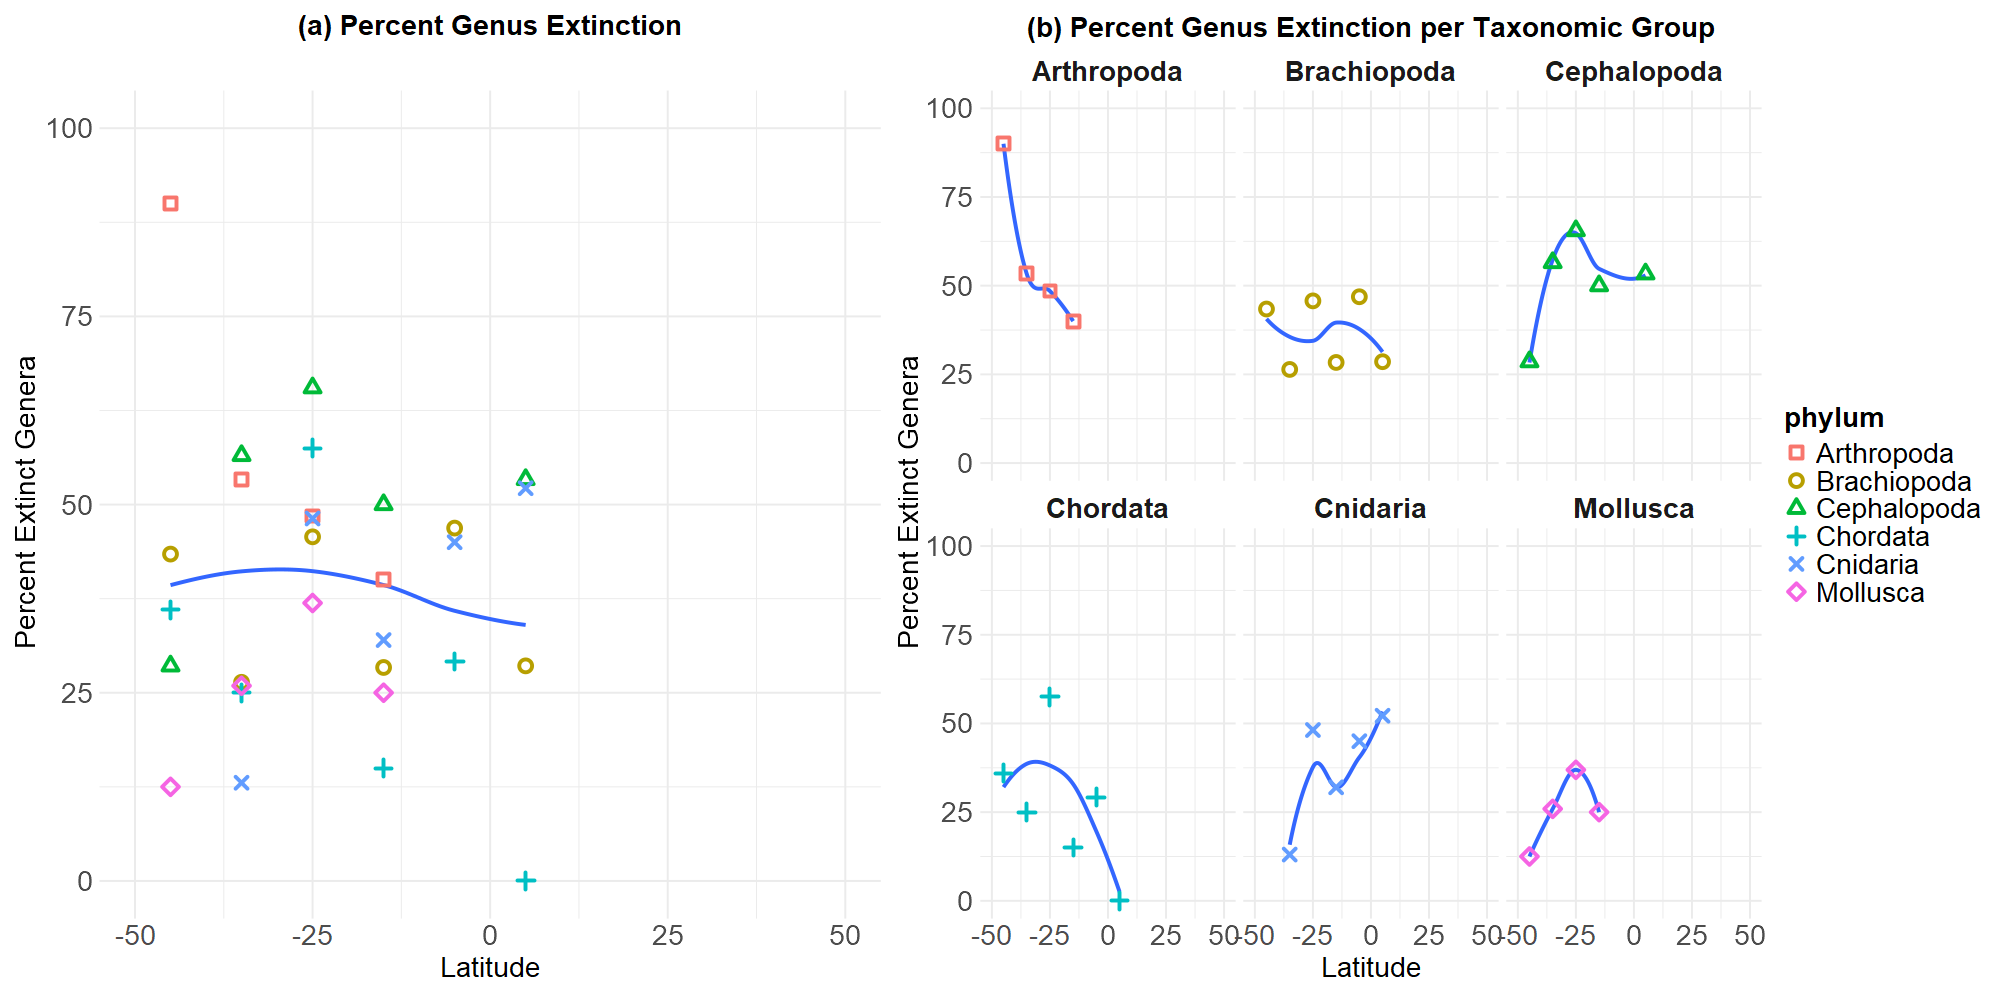

In [93]:
options(repr.plot.width = 20, repr.plot.height = 10, repr.plot.res = 100)

# Define nektonic classes specific to Mollusca
nektonic_classes <- c("Cephalopoda")

# Recode phylum for Cephalopoda and keep all occurrences
stage_bin_mod <- filtered_stage_bin %>%
  mutate(phylum = ifelse(phylum == "Mollusca" & class %in% nektonic_classes, 
                         "Cephalopoda", 
                         phylum))%>%
  filter(latbin<30)

# Count total genera per phylum and latbin (all time, not filtering early_interval)
genera_phyla_latbin <- stage_bin_mod %>%
  group_by(latbin, phylum) %>%
  summarise(num_genera = n_distinct(genus), .groups = "drop")

# Count extinct genera per phylum and latbin
extinct_by_lat <- stage_bin_mod %>%
  filter(ex == 1) %>%
  group_by(latbin, phylum) %>%
  summarise(extinct_genera = n_distinct(genus), .groups = "drop")

# Combine and calculate percent extinction; keep all latbins
generic_extinction <- genera_phyla_latbin %>%
  left_join(extinct_by_lat, by = c("latbin", "phylum")) %>%
  mutate(
    extinct_genera = replace_na(extinct_genera, 0),
    percent = extinct_genera / num_genera * 100
  ) %>%
  # Optionally restrict latbin range for plotting
  filter(latbin >= -50, latbin <= 40)

generic_extinction <- generic_extinction %>%
  filter(num_genera > 0)
# ----- Plots -----

generic_extinction_scatter_all <- ggplot(generic_extinction, aes(x = latbin, y = percent)) +
  geom_smooth(method = "loess", span = 1, se = FALSE) +
  geom_point(aes(color = phylum, shape = phylum), size = 3, stroke = 1.5) +
  scale_fill_manual(values = setNames(okabe_ito_10, phylum))+
  scale_shape_manual(values = 0:10) +
  ylim(0, 100) +
  xlim(-50, 50) +
  labs(
    x = "Latitude",
    y = "Percent Extinct Genera",
    title = "Percent Extinct Genera per Latitudinal Bin"
  ) +
  theme_minimal() +
  theme(
  plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),

  # Axis labels
  axis.title = element_text(size = 20),

  # Tick labels
  axis.text = element_text(size = 20),

  # Facet strip titles
  strip.text = element_text(size = 20, face = "bold"),

  # Legend title and text
  legend.title = element_text(size = 20, face = "bold"),
  legend.text = element_text(size = 20)
)

generic_extinction_scatter_facet <- ggplot(generic_extinction, aes(x = latbin, y = percent)) +
  geom_smooth(method = "loess", span = 1, se = FALSE) +
  geom_point(aes(color = phylum, shape = phylum), size = 3, stroke = 1.5) +
  scale_fill_manual(values = setNames(okabe_ito_10, phylum)) +
  scale_shape_manual(values = 0:10) +
  facet_wrap(~phylum) +
  ylim(0, 100) +
  xlim(-50, 50) +
  labs(
    x = "Latitude",
    y = "Percent Extinct Genera",
    title = "Percent Extinct Genera per Latitudinal Bin"
  ) +
  theme_minimal() +
  theme(
  plot.title = element_text(hjust = 0.5, size = 20, face = "bold"),

  # Axis labels
  axis.title = element_text(size = 20),

  # Tick labels
  axis.text = element_text(size = 20),

  # Facet strip titles
  strip.text = element_text(size = 20, face = "bold"),

  # Legend title and text
  legend.title = element_text(size = 20, face = "bold"),
  legend.text = element_text(size = 20)
)

per_taxa_extinction <- (generic_extinction_scatter_all + 
                         ggtitle("(a) Percent Genus Extinction") +
                         theme(legend.position = "none")) +
                       (generic_extinction_scatter_facet + 
                         ggtitle("(b) Percent Genus Extinction per Taxonomic Group")) +
                       theme(legend.position = "right")

per_taxa_extinction

# ggsave("../figures/per_taxa_extinction_MI.png", plot = per_taxa_extinction, width = 14, height = 6, dpi = 300)

**Figure 11:** (a) Per bin extinction intensity before standardization of all included taxa (b) Non-standardized extinction gradients of each phyla.